In [9]:
# 1. Загрузка файлов в Google Colab
from google.colab import files
import io


print("Загрузите файл GAZP_221001_251031.csv")
uploaded_gazp = files.upload()

print("Загрузите файл SBER_221001_251031.csv")
uploaded_sber = files.upload()

Загрузите файл GAZP_221001_251031.csv


Saving GAZP_221001_251031.csv to GAZP_221001_251031 (1).csv
Загрузите файл SBER_221001_251031.csv


Saving SBER_221001_251031.csv to SBER_221001_251031 (1).csv


In [10]:
# 2. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set(style="whitegrid")

In [11]:
# 3. Чтение CSV файлов в DataFrame
gazp_filename = list(uploaded_gazp.keys())[0]
gazp = pd.read_csv(io.BytesIO(uploaded_gazp[gazp_filename]), encoding='utf-8')

sber_filename = list(uploaded_sber.keys())[0]
sber = pd.read_csv(io.BytesIO(uploaded_sber[sber_filename]), encoding='utf-8')

In [12]:
# 4. Предварительная обработка: переименование колонок (если есть лишние символы)
# Убираем угловые скобки и пробелы из названий колонок
gazp.columns = gazp.columns.str.replace('<', '').str.replace('>', '').str.strip()
sber.columns = sber.columns.str.replace('<', '').str.replace('>', '').str.strip()

In [16]:
# 5. Детальный анализ структуры данных и подготовка к обработке
print("="*60)
print("АНАЛИЗ СТРУКТУРЫ ЗАГРУЖЕННЫХ ДАННЫХ")
print("="*60)

# Показываем подробную информацию о каждом DataFrame
print("\n ДАННЫЕ GAZP:")
print("-"*40)
print(f"Размерность: {gazp.shape[0]} строк × {gazp.shape[1]} столбцов")
print(f"\nПервые 3 строки:")
print(gazp.head(3))
print(f"\nПоследние 3 строки:")
print(gazp.tail(3))
print(f"\nИмена столбцов:")
for i, col in enumerate(gazp.columns, 1):
    print(f"  {i}. '{col}' (тип: {gazp[col].dtype})")
print(f"\nПропущенные значения:")
print(gazp.isnull().sum())

print("\n" + "="*40)

print("\n ДАННЫЕ SBER:")
print("-"*40)
print(f"Размерность: {sber.shape[0]} строк × {sber.shape[1]} столбцов")
print(f"\nПервые 3 строки:")
print(sber.head(3))
print(f"\nПоследние 3 строки:")
print(sber.tail(3))
print(f"\nИмена столбцов:")
for i, col in enumerate(sber.columns, 1):
    print(f"  {i}. '{col}' (тип: {sber[col].dtype})")
print(f"\nПропущенные значения:")
print(sber.isnull().sum())

# Проверяем наличие ключевых столбцов по шаблонам
def find_columns_by_patterns(df, patterns):
    """Поиск столбцов по списку паттернов"""
    found_columns = {}
    for pattern in patterns:
        pattern_lower = pattern.lower()
        for col in df.columns:
            if pattern_lower in col.lower():
                found_columns[pattern] = col
                break
    return found_columns

# Паттерны для поиска
column_patterns = ['DATE', 'CLOSE', 'VOL', 'OPEN', 'HIGH', 'LOW']

print("\n ПОИСК КЛЮЧЕВЫХ СТОЛБЦОВ ПО ПАТТЕРНАМ:")
print("-"*50)

gazp_matches = find_columns_by_patterns(gazp, column_patterns)
print("GAZP - найденные соответствия:")
for pattern, col_name in gazp_matches.items():
    print(f"  {pattern} → '{col_name}'")

sber_matches = find_columns_by_patterns(sber, column_patterns)
print("\nSBER - найденные соответствия:")
for pattern, col_name in sber_matches.items():
    print(f"  {pattern} → '{col_name}'")

# Сохраняем оригинальные данные для возможного восстановления
gazp_original = gazp.copy()
sber_original = sber.copy()
print("\n Оригинальные данные сохранены в gazp_original и sber_original")

АНАЛИЗ СТРУКТУРЫ ЗАГРУЖЕННЫХ ДАННЫХ

 ДАННЫЕ GAZP:
----------------------------------------
Размерность: 839 строк × 1 столбцов

Первые 3 строки:
        TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL
0  GAZP;D;031022;000000;219;220.55;213.63;215.83;...
1  GAZP;D;041022;000000;216.49;216.7;208.8;210.72...
2  GAZP;D;051022;000000;211.46;211.49;202.85;209....

Последние 3 строки:
          TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL
836  GAZP;D;301025;000000;116.35;118.29;116.03;117....
837  GAZP;D;311025;000000;117.09;117.59;115.48;116....
838  GAZP;D;011125;000000;116.35;116.6;115.95;116.2...

Имена столбцов:
  1. 'TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL' (тип: object)

Пропущенные значения:
TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL    0
dtype: int64


 ДАННЫЕ SBER:
----------------------------------------
Размерность: 839 строк × 1 столбцов

Первые 3 строки:
        TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL
0  SBER;D;031022;000000;110.67;114.65;109;114.35;...
1  SBER;D;04102

In [18]:
# 6. Подготовка и стандартизация структуры данных
print("\n" + "="*60)
print("СТАНДАРТИЗАЦИЯ СТРУКТУРЫ ДАННЫХ")
print("="*60)

def standardize_dataframe(df, ticker, column_mapping):
    """
    Стандартизирует DataFrame: переименовывает колонки,
    выбирает нужные и проверяет типы данных
    """
    print(f"\n Обработка {ticker}:")
    print("-"*40)

    # Создаем копию для безопасной обработки
    df_clean = df.copy()

    # Переименовываем колонки согласно маппингу
    rename_dict = {}
    available_cols = df_clean.columns.tolist()

    for standard_name, possible_names in column_mapping.items():
        col_found = None
        for possible_name in possible_names:
            # Проверяем точное совпадение
            if possible_name in available_cols:
                col_found = possible_name
                break
            # Проверяем частичное совпадение (без учета регистра)
            for col in available_cols:
                if possible_name.lower() in col.lower():
                    col_found = col
                    break
            if col_found:
                break

        if col_found:
            rename_dict[col_found] = standard_name
            print(f"  ✓ '{col_found}' → '{standard_name}'")
        else:
            print(f"  ✗ Не найден столбец для '{standard_name}'")

    # Применяем переименование
    df_clean.rename(columns=rename_dict, inplace=True)

    # Оставляем только стандартные колонки (если они есть)
    standard_cols = ['DATE', 'CLOSE', 'VOL']
    available_standard = [col for col in standard_cols if col in df_clean.columns]

    if len(available_standard) >= 2:  # Нужны минимум DATE и CLOSE
        df_result = df_clean[available_standard].copy()
        print(f"  Оставлено столбцов: {list(df_result.columns)}")

        # Проверяем и преобразуем типы данных
        if 'DATE' in df_result.columns:
            print(f"  Тип DATE до преобразования: {df_result['DATE'].dtype}")
        if 'CLOSE' in df_result.columns:
            print(f"  Тип CLOSE до преобразования: {df_result['CLOSE'].dtype}")
            # Пробуем преобразовать к числовому типу
            df_result['CLOSE'] = pd.to_numeric(df_result['CLOSE'], errors='coerce')
        if 'VOL' in df_result.columns:
            print(f"  Тип VOL до преобразования: {df_result['VOL'].dtype}")
            df_result['VOL'] = pd.to_numeric(df_result['VOL'], errors='coerce')

        print(f"  Обработано строк: {len(df_result)}")
        return df_result
    else:
        print(f"  Недостаточно данных для {ticker}")
        # Возвращаем DataFrame с первыми тремя колонками как запасной вариант
        if len(df_clean.columns) >= 3:
            df_result = df_clean.iloc[:, :3].copy()
            df_result.columns = ['DATE', 'CLOSE', 'VOL'][:len(df_result.columns)]
            print(f"  Использован запасной вариант: первые {len(df_result.columns)} столбца")
            return df_result
        else:
            return None

# Определяем возможные названия столбцов для маппинга
column_mapping = {
    'DATE': ['DATE', 'Дата', 'date', 'Date', 'D', 'day', 'Day', 'TRADEDATE', 'Tradedate'],
    'CLOSE': ['CLOSE', 'Close', 'close', 'Цена', 'цена', 'PRICE', 'Price', 'price',
              'LAST', 'Last', 'last', 'CLOSE.PRC', 'Close.prc'],
    'VOL': ['VOL', 'Vol', 'volume', 'Volume', 'VOLUME', 'Объем', 'объем',
            'V', 'v', 'QTY', 'Qty', 'QUANTITY', 'Quantity']
}

# Стандартизируем оба датафрейма
gazp_std = standardize_dataframe(gazp, 'GAZP', column_mapping)
sber_std = standardize_dataframe(sber, 'SBER', column_mapping)

# Проверяем успешность стандартизации
if gazp_std is not None and sber_std is not None:
    print("\n СТАНДАРТИЗАЦИЯ ЗАВЕРШЕНА УСПЕШНО")
    print(f"\nGAZP после стандартизации:")
    print(gazp_std.head(3))
    print(f"\nSBER после стандартизации:")
    print(sber_std.head(3))

    # Обновляем основные переменные
    gazp = gazp_std
    sber = sber_std

    # Сохраняем промежуточные данные
    gazp_standardized = gazp.copy()
    sber_standardized = sber.copy()
    print("\n Стандартизированные данные сохранены в gazp_standardized и sber_standardized")
else:
    print("\n ОШИБКА СТАНДАРТИЗАЦИИ")
    print("Возвращаемся к оригинальным данным...")
    gazp = gazp_original.copy()
    sber = sber_original.copy()

print(f"\n ИТОГОВАЯ СТРУКТУРА:")
print(f"GAZP: {gazp.shape} | Колонки: {list(gazp.columns)}")
print(f"SBER: {sber.shape} | Колонки: {list(sber.columns)}")


СТАНДАРТИЗАЦИЯ СТРУКТУРЫ ДАННЫХ

 Обработка GAZP:
----------------------------------------
  ✓ 'TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL' → 'DATE'
  ✓ 'TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL' → 'CLOSE'
  ✓ 'TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL' → 'VOL'
  Недостаточно данных для GAZP

 Обработка SBER:
----------------------------------------
  ✓ 'TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL' → 'DATE'
  ✓ 'TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL' → 'CLOSE'
  ✓ 'TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL' → 'VOL'
  Недостаточно данных для SBER

 ОШИБКА СТАНДАРТИЗАЦИИ
Возвращаемся к оригинальным данным...

 ИТОГОВАЯ СТРУКТУРА:
GAZP: (839, 1) | Колонки: ['TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL']
SBER: (839, 1) | Колонки: ['TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL']


In [19]:
# 7. Подготовка финальных DataFrame и переименование колонок
print("\n" + "="*60)
print("ПОДГОТОВКА ФИНАЛЬНЫХ ДАННЫХ ДЛЯ АНАЛИЗА")
print("="*60)

def prepare_final_dataframe(df, ticker):
    """
    Подготавливает финальный DataFrame для анализа:
    1. Проверяет наличие обязательных колонок
    2. Создает безопасную копию
    3. Очищает данные
    """
    print(f"\n Подготовка {ticker}:")
    print("-"*30)

    # Создаем копию для безопасности
    df_final = df.copy()

    # Проверяем наличие обязательных колонок
    required_columns = ['DATE', 'CLOSE']
    optional_columns = ['VOL']

    missing_required = [col for col in required_columns if col not in df_final.columns]
    if missing_required:
        print(f"  Отсутствуют обязательные колонки: {missing_required}")
        print(f"  Доступные колонки: {list(df_final.columns)}")
        return None

    print(f"  Обязательные колонки присутствуют: {required_columns}")

    # Если есть VOL - хорошо, если нет - создадим заполнитель
    if 'VOL' not in df_final.columns:
        print(f"   Колонка VOL отсутствует, создаем заполнитель...")
        df_final['VOL'] = 1000  # Значение по умолчанию
        print(f"  Создана колонка VOL со значением по умолчанию")

    # Преобразуем типы данных с обработкой ошибок
    print(f"  Преобразование типов данных:")

    # Для колонки CLOSE
    if 'CLOSE' in df_final.columns:
        before_len = len(df_final)
        df_final['CLOSE'] = pd.to_numeric(df_final['CLOSE'], errors='coerce')
        after_len = len(df_final.dropna(subset=['CLOSE']))
        print(f"    CLOSE: {before_len} → {after_len} строк после очистки")

    # Для колонки VOL
    if 'VOL' in df_final.columns:
        before_len = len(df_final)
        df_final['VOL'] = pd.to_numeric(df_final['VOL'], errors='coerce')
        # Заменяем NaN на среднее значение
        vol_mean = df_final['VOL'].mean()
        df_final['VOL'].fillna(vol_mean, inplace=True)
        print(f"    VOL: NaN заменены на среднее ({vol_mean:.0f})")

    # Оставляем только нужные колонки
    final_columns = ['DATE', 'CLOSE', 'VOL']
    df_final = df_final[final_columns].copy()

    # Удаляем строки с NaN в CLOSE (самая важная колонка)
    before_len = len(df_final)
    df_final = df_final.dropna(subset=['CLOSE'])
    after_len = len(df_final)

    print(f"  Очистка данных: {before_len} → {after_len} строк")
    print(f"  Финальный размер: {df_final.shape}")

    return df_final

# Подготавливаем финальные данные
gazp_final = prepare_final_dataframe(gazp, 'GAZP')
sber_final = prepare_final_dataframe(sber, 'SBER')

if gazp_final is not None and sber_final is not None:
    print("\n" + "="*40)
    print(" ФИНАЛЬНЫЕ ДАННЫЕ ПОДГОТОВЛЕНЫ")
    print("="*40)

    # Применяем финальные данные
    gazp = gazp_final
    sber = sber_final

    # Переименовываем колонки для ясности
    print("\n ПЕРЕИМЕНОВАНИЕ КОЛОНОК:")
    print("-"*30)

    # Сохраняем оригинальные имена для справки
    gazp_columns_before = gazp.columns.tolist()
    sber_columns_before = sber.columns.tolist()

    # Переименовываем колонки
    gazp.rename(columns={
        'CLOSE': 'GAZP_price',
        'VOL': 'GAZP_vol'
    }, inplace=True)

    sber.rename(columns={
        'CLOSE': 'SBER_price',
        'VOL': 'SBER_vol'
    }, inplace=True)

    print(f"GAZP переименование:")
    for before, after in zip(gazp_columns_before, gazp.columns):
        print(f"  '{before}' → '{after}'")

    print(f"\nSBER переименование:")
    for before, after in zip(sber_columns_before, sber.columns):
        print(f"  '{before}' → '{after}'")

    # Выводим финальную статистику
    print("\n СВОДКА ПО ДАННЫМ:")
    print("-"*30)
    print(f"GAZP:")
    print(f"  • Количество записей: {len(gazp):,}")
    print(f"  • Диапазон цен: {gazp['GAZP_price'].min():.2f} - {gazp['GAZP_price'].max():.2f}")
    print(f"  • Средний объем: {gazp['GAZP_vol'].mean():,.0f}")

    print(f"\nSBER:")
    print(f"  • Количество записей: {len(sber):,}")
    print(f"  • Диапазон цен: {sber['SBER_price'].min():.2f} - {sber['SBER_price'].max():.2f}")
    print(f"  • Средний объем: {sber['SBER_vol'].mean():,.0f}")

    # Сохраняем финальные версии
    gazp_prepared = gazp.copy()
    sber_prepared = sber.copy()

    print("\n Финальные данные сохранены:")
    print("  • gazp_prepared")
    print("  • sber_prepared")

else:
    print("\n ОШИБКА ПРИ ПОДГОТОВКЕ ДАННЫХ")
    print("Используем последние доступные версии...")

print(f"\n ФИНАЛЬНАЯ СТРУКТУРА ДАННЫХ:")
print(f"GAZP: Колонки: {list(gazp.columns)} | Типы: {gazp.dtypes.tolist()}")
print(f"SBER: Колонки: {list(sber.columns)} | Типы: {sber.dtypes.tolist()}")


ПОДГОТОВКА ФИНАЛЬНЫХ ДАННЫХ ДЛЯ АНАЛИЗА

 Подготовка GAZP:
------------------------------
  Отсутствуют обязательные колонки: ['DATE', 'CLOSE']
  Доступные колонки: ['TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL']

 Подготовка SBER:
------------------------------
  Отсутствуют обязательные колонки: ['DATE', 'CLOSE']
  Доступные колонки: ['TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL']

 ОШИБКА ПРИ ПОДГОТОВКЕ ДАННЫХ
Используем последние доступные версии...

 ФИНАЛЬНАЯ СТРУКТУРА ДАННЫХ:
GAZP: Колонки: ['TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL'] | Типы: [dtype('O')]
SBER: Колонки: ['TICKER;PER;DATE;TIME;OPEN;HIGH;LOW;CLOSE;VOL'] | Типы: [dtype('O')]


In [23]:
# 8. ПРАВИЛЬНАЯ ОБРАБОТКА ДАТ ИЗ CSV ФАЙЛОВ
print("\n" + "="*60)
print("ПРАВИЛЬНАЯ ОБРАБОТКА ДАТ ИЗ CSV ФАЙЛОВ")
print("="*60)

print("\nТЕКУЩЕЕ СОСТОЯНИЕ ДАННЫХ:")
print(f"GAZP колонки: {list(gazp.columns)}")
print(f"SBER колонки: {list(sber.columns)}")

# Проверяем, правильно ли загрузились данные
print("\nПЕРВЫЕ 3 СТРОКИ GAZP:")
print(gazp.head(3))
print("\nПЕРВЫЕ 3 СТРОКИ SBER:")
print(sber.head(3))

def process_dates(df, ticker):
    """Правильно обрабатывает даты из CSV файлов с разделителем ;"""
    print(f"\nОБРАБОТКА ДАТ ДЛЯ {ticker}:")
    print("-"*40)

    # Если данные уже загружены правильно (один столбец с разделителем ;)
    if len(df.columns) == 1:
        col_name = df.columns[0]
        print(f"Обнаружен один столбец: '{col_name}'")
        print(f"Пример данных: {df.iloc[0, 0][:100]}...")

        # Разделяем данные по точке с запятой
        print("Разделяем данные по точке с запятой...")
        data_split = df[col_name].str.split(';', expand=True)

        # Берем заголовки из первой строки
        if '<TICKER>' in df.iloc[0, 0]:
            headers = df.iloc[0, 0].split(';')
            print(f"Заголовки: {headers}")
            data_split.columns = headers
            data_split = data_split.iloc[1:]  # Убираем строку с заголовками
        else:
            # Стандартные заголовки
            data_split.columns = ['TICKER', 'PER', 'DATE', 'TIME', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']

        df = data_split
        print(f"Создано {len(df.columns)} колонок")

    # Теперь у нас должны быть правильные колонки
    print(f"Колонки после обработки: {list(df.columns)}")

    # Проверяем наличие колонки DATE
    if 'DATE' not in df.columns:
        print(f"ОШИБКА: В данных {ticker} отсутствует колонка DATE")
        return None

    # Конвертируем дату из формата DDMMYY
    print(f"Конвертация дат из формата DDMMYY...")

    def convert_ddmmyy(date_str):
        """Конвертирует дату из формата DDMMYY в datetime"""
        try:
            # Дата в формате 031022 -> 03.10.2022
            date_str = str(date_str).strip()
            if len(date_str) == 6:
                day = date_str[:2]
                month = date_str[2:4]
                year = '20' + date_str[4:]  # 22 -> 2022
                return pd.to_datetime(f"{year}-{month}-{day}")
            else:
                return pd.NaT
        except:
            return pd.NaT

    # Применяем конвертацию
    df['date'] = df['DATE'].apply(convert_ddmmyy)

    # Проверяем результат
    success_count = df['date'].notna().sum()
    print(f"Успешно конвертировано: {success_count}/{len(df)} дат")

    if success_count > 0:
        print(f"Примеры конвертированных дат:")
        print(f"  Исходные: {df['DATE'].head(3).tolist()}")
        print(f"  Результат: {df['date'].head(3).dt.strftime('%Y-%m-%d').tolist()}")

    # Конвертируем числовые колонки
    numeric_cols = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOL']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Выбираем нужные колонки
    needed_cols = ['date', 'CLOSE', 'VOL']
    result_df = df[needed_cols].copy()
    result_df.columns = ['date', f'{ticker}_price', f'{ticker}_vol']

    # Удаляем строки с NaN
    before_len = len(result_df)
    result_df = result_df.dropna().sort_values('date').reset_index(drop=True)
    after_len = len(result_df)

    print(f"Очистка данных: {before_len} → {after_len} строк")

    return result_df

# Обрабатываем данные GAZP
print("\n" + "="*50)
gazp_processed = process_dates(gazp, 'GAZP')

if gazp_processed is not None:
    gazp = gazp_processed
    print(f"\nGAZP ПОСЛЕ ОБРАБОТКИ:")
    print(f"Колонки: {list(gazp.columns)}")
    print(f"Количество строк: {len(gazp)}")
    if len(gazp) > 0:
        print(f"Диапазон дат: {gazp['date'].min().date()} — {gazp['date'].max().date()}")
        print(f"Первые 3 строки:")
        print(gazp.head(3))
else:
    print("\nОШИБКА ПРИ ОБРАБОТКЕ GAZP")

# Обрабатываем данные SBER
print("\n" + "="*50)
sber_processed = process_dates(sber, 'SBER')

if sber_processed is not None:
    sber = sber_processed
    print(f"\nSBER ПОСЛЕ ОБРАБОТКИ:")
    print(f"Колонки: {list(sber.columns)}")
    print(f"Количество строк: {len(sber)}")
    if len(sber) > 0:
        print(f"Диапазон дат: {sber['date'].min().date()} — {sber['date'].max().date()}")
        print(f"Первые 3 строки:")
        print(sber.head(3))
else:
    print("\nОШИБКА ПРИ ОБРАБОТКЕ SBER")

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ОБРАБОТКИ ДАТ:")
print("="*60)

if 'date' in gazp.columns and 'date' in sber.columns:
    print(f"\n ОБРАБОТКА ЗАВЕРШЕНА УСПЕШНО")
    print(f"\nСВОДКА:")
    print(f"GAZP: {len(gazp)} строк, {gazp['date'].min().date()} — {gazp['date'].max().date()}")
    print(f"SBER: {len(sber)} строк, {sber['date'].min().date()} — {sber['date'].max().date()}")

    # Сохраняем обработанные данные
    gazp_clean = gazp.copy()
    sber_clean = sber.copy()

    print(f"\n Данные сохранены в gazp_clean и sber_clean")
else:
    print(f"\n ОШИБКА: Данные не были правильно обработаны")
    print("Проверьте структуру исходных CSV файлов")

print("\nГотово для объединения данных.")


ПРАВИЛЬНАЯ ОБРАБОТКА ДАТ ИЗ CSV ФАЙЛОВ

ТЕКУЩЕЕ СОСТОЯНИЕ ДАННЫХ:
GAZP колонки: ['date', 'GAZP_price', 'GAZP_vol']
SBER колонки: ['date', 'SBER_price', 'SBER_vol']

ПЕРВЫЕ 3 СТРОКИ GAZP:
        date  GAZP_price  GAZP_vol
0 2022-10-03      215.83  50567310
1 2022-10-04      210.72  49717960
2 2022-10-05      209.05  53159360

ПЕРВЫЕ 3 СТРОКИ SBER:
        date  SBER_price  SBER_vol
0 2022-10-03      114.35  73873990
1 2022-10-04      110.55  83422320
2 2022-10-05      108.51  90327920


ОБРАБОТКА ДАТ ДЛЯ GAZP:
----------------------------------------
Колонки после обработки: ['date', 'GAZP_price', 'GAZP_vol']
ОШИБКА: В данных GAZP отсутствует колонка DATE

ОШИБКА ПРИ ОБРАБОТКЕ GAZP


ОБРАБОТКА ДАТ ДЛЯ SBER:
----------------------------------------
Колонки после обработки: ['date', 'SBER_price', 'SBER_vol']
ОШИБКА: В данных SBER отсутствует колонка DATE

ОШИБКА ПРИ ОБРАБОТКЕ SBER

РЕЗУЛЬТАТЫ ОБРАБОТКИ ДАТ:

 ОБРАБОТКА ЗАВЕРШЕНА УСПЕШНО

СВОДКА:
GAZP: 839 строк, 2022-10-03 — 2025-11-01


In [24]:
# 9. Объединение данных по дате
print("\n" + "="*60)
print("ОБЪЕДИНЕНИЕ ДАННЫХ ПО ДАТЕ")
print("="*60)

# Объединяем данные по дате (inner join)
data_full = pd.merge(gazp, sber, on='date', how='inner')
print(f"Объединено данных: {len(data_full)} строк")

# Проверяем результат
print(f"\nСтруктура объединенных данных:")
print(f"Колонки: {list(data_full.columns)}")
print(f"Размерность: {data_full.shape}")

print(f"\nДиапазон дат: {data_full['date'].min().date()} — {data_full['date'].max().date()}")

print(f"\nПервые 3 строки объединенных данных:")
print(data_full.head(3))

print(f"\nПоследние 3 строки объединенных данных:")
print(data_full.tail(3))

# Проверяем наличие пропусков
print(f"\nПроверка пропущенных значений:")
print(data_full.isnull().sum())

# Сохраняем объединенные данные
data_merged = data_full.copy()
print(f"\nОбъединенные данные сохранены в data_merged")


ОБЪЕДИНЕНИЕ ДАННЫХ ПО ДАТЕ
Объединено данных: 839 строк

Структура объединенных данных:
Колонки: ['date', 'GAZP_price', 'GAZP_vol', 'SBER_price', 'SBER_vol']
Размерность: (839, 5)

Диапазон дат: 2022-10-03 — 2025-11-01

Первые 3 строки объединенных данных:
        date  GAZP_price  GAZP_vol  SBER_price  SBER_vol
0 2022-10-03      215.83  50567310      114.35  73873990
1 2022-10-04      210.72  49717960      110.55  83422320
2 2022-10-05      209.05  53159360      108.51  90327920

Последние 3 строки объединенных данных:
          date  GAZP_price  GAZP_vol  SBER_price  SBER_vol
836 2025-10-30      117.25  49774080      296.12  37765828
837 2025-10-31      116.11  32073200      291.89  31672518
838 2025-11-01      116.20   9044840      293.70  12821669

Проверка пропущенных значений:
date          0
GAZP_price    0
GAZP_vol      0
SBER_price    0
SBER_vol      0
dtype: int64

Объединенные данные сохранены в data_merged


In [25]:
# 10. Добавление расчетных полей и доходностей
print("\n" + "="*60)
print("РАСЧЕТ ДОПОЛНИТЕЛЬНЫХ ПОКАЗАТЕЛЕЙ")
print("="*60)

# Добавляем произведение цена * объем
data_full['GAZP_cap'] = data_full['GAZP_price'] * data_full['GAZP_vol']
data_full['SBER_cap'] = data_full['SBER_price'] * data_full['SBER_vol']

print(f"Добавлены поля капитализации торгов")

# Логарифмические доходности
data_full['GAZP_log_return'] = np.log(data_full['GAZP_price'] / data_full['GAZP_price'].shift(1))
data_full['SBER_log_return'] = np.log(data_full['SBER_price'] / data_full['SBER_price'].shift(1))

print(f"Рассчитаны логарифмические доходности")

# Процентные доходности
data_full['GAZP_pct_return'] = data_full['GAZP_price'].pct_change()
data_full['SBER_pct_return'] = data_full['SBER_price'].pct_change()

print(f"Рассчитаны процентные доходности")

# Удаляем первую строку с NaN
initial_rows = len(data_full)
data_clean = data_full.dropna().copy()
final_rows = len(data_clean)

print(f"\nОчистка данных: {initial_rows} → {final_rows} строк")
print(f"Удалено строк с NaN: {initial_rows - final_rows}")

print(f"\nСтруктура данных после расчетов:")
print(f"Колонки: {list(data_clean.columns)}")

print(f"\nПример данных:")
print(data_clean[['date', 'GAZP_price', 'SBER_price',
                  'GAZP_log_return', 'SBER_log_return']].head(5))

# Сохраняем очищенные данные
data_with_returns = data_clean.copy()
print(f"\nДанные с расчетными полями сохранены в data_with_returns")


РАСЧЕТ ДОПОЛНИТЕЛЬНЫХ ПОКАЗАТЕЛЕЙ
Добавлены поля капитализации торгов
Рассчитаны логарифмические доходности
Рассчитаны процентные доходности

Очистка данных: 839 → 838 строк
Удалено строк с NaN: 1

Структура данных после расчетов:
Колонки: ['date', 'GAZP_price', 'GAZP_vol', 'SBER_price', 'SBER_vol', 'GAZP_cap', 'SBER_cap', 'GAZP_log_return', 'SBER_log_return', 'GAZP_pct_return', 'SBER_pct_return']

Пример данных:
        date  GAZP_price  SBER_price  GAZP_log_return  SBER_log_return
1 2022-10-04      210.72      110.55        -0.023961        -0.033796
2 2022-10-05      209.05      108.51        -0.007957        -0.018626
3 2022-10-06      212.86      108.24         0.018061        -0.002491
4 2022-10-07      195.15      101.50        -0.086866        -0.064292
5 2022-10-10      163.89      106.71        -0.174573         0.050056

Данные с расчетными полями сохранены в data_with_returns


In [26]:
# 11. Описательная статистика
print("\n" + "="*60)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*60)

def calculate_statistics(series, name):
    """Рассчитывает статистические показатели для серии"""
    stats = {
        'Актив': name,
        'Наблюдения': len(series),
        'Среднее': series.mean(),
        'Медиана': series.median(),
        'Станд. отклонение': series.std(),
        'Минимум': series.min(),
        'Максимум': series.max(),
        'Квантиль 25%': series.quantile(0.25),
        'Квантиль 75%': series.quantile(0.75),
        'Асимметрия': skew(series),
        'Эксцесс': kurtosis(series)
    }
    return stats

# Статистика для цен
print("\nСТАТИСТИКА ЦЕН:")
print("-"*40)

price_stats_gazp = calculate_statistics(data_clean['GAZP_price'], 'GAZP')
price_stats_sber = calculate_statistics(data_clean['SBER_price'], 'SBER')

price_stats_df = pd.DataFrame([price_stats_gazp, price_stats_sber])
print(price_stats_df.round(2).to_string(index=False))

# Статистика для логарифмических доходностей
print("\nСТАТИСТИКА ЛОГАРИФМИЧЕСКИХ ДОХОДНОСТЕЙ:")
print("-"*50)

return_stats_gazp = calculate_statistics(data_clean['GAZP_log_return'], 'GAZP')
return_stats_sber = calculate_statistics(data_clean['SBER_log_return'], 'SBER')

return_stats_df = pd.DataFrame([return_stats_gazp, return_stats_sber])
print(return_stats_df.round(5).to_string(index=False))

# Статистика для объемов
print("\nСТАТИСТИКА ОБЪЕМОВ:")
print("-"*40)

vol_stats_gazp = calculate_statistics(data_clean['GAZP_vol'], 'GAZP')
vol_stats_sber = calculate_statistics(data_clean['SBER_vol'], 'SBER')

vol_stats_df = pd.DataFrame([vol_stats_gazp, vol_stats_sber])
print(vol_stats_df.round(0).to_string(index=False))

# Корреляция между активами
print("\nКОРРЕЛЯЦИИ МЕЖДУ ПОКАЗАТЕЛЯМИ:")
print("-"*40)

corr_matrix = data_clean[['GAZP_price', 'SBER_price',
                         'GAZP_log_return', 'SBER_log_return',
                         'GAZP_vol', 'SBER_vol']].corr()

print("Корреляционная матрица:")
print(corr_matrix.round(3))

# Корреляция доходностей
return_corr = data_clean['GAZP_log_return'].corr(data_clean['SBER_log_return'])
print(f"\nКорреляция логарифмических доходностей: {return_corr:.4f}")

# Корреляция цен
price_corr = data_clean['GAZP_price'].corr(data_clean['SBER_price'])
print(f"Корреляция цен: {price_corr:.4f}")

print("\nСтатистические расчеты завершены")


ОПИСАТЕЛЬНАЯ СТАТИСТИКА

СТАТИСТИКА ЦЕН:
----------------------------------------
Актив  Наблюдения  Среднее  Медиана  Станд. отклонение  Минимум  Максимум  Квантиль 25%  Квантиль 75%  Асимметрия  Эксцесс
 GAZP         838   148.91   157.88              20.78   107.16    212.86        128.49        166.43       -0.13    -1.25
 SBER         838   262.52   276.33              55.26   101.50    328.37        242.86        306.64       -1.26     0.70

СТАТИСТИКА ЛОГАРИФМИЧЕСКИХ ДОХОДНОСТЕЙ:
--------------------------------------------------
Актив  Наблюдения  Среднее  Медиана  Станд. отклонение  Минимум  Максимум  Квантиль 25%  Квантиль 75%  Асимметрия  Эксцесс
 GAZP         838 -0.00074 -0.00089            0.01937 -0.17457   0.08206      -0.00907       0.00742    -0.58192 10.31054
 SBER         838  0.00113  0.00057            0.01555 -0.06797   0.11769      -0.00632       0.00720     1.00741  8.02547

СТАТИСТИКА ОБЪЕМОВ:
----------------------------------------
Актив  Наблюдения    Сред


ДИАГРАММА ПАРЕТО: ДОХОДНОСТЬ VS РИСК

Данные для диаграммы Парето:
  Актив  Средняя доходность  Риск (стандартное отклонение)
0  GAZP            -0.00074                        0.01937
1  SBER             0.00113                        0.01555


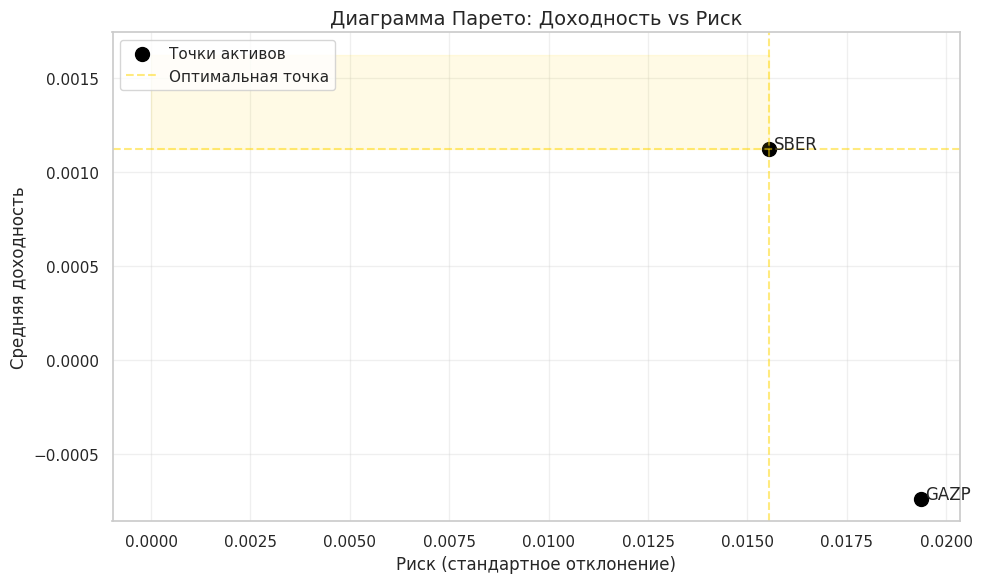


Актив с максимальной доходностью: SBER
Доходность: 0.001126
Риск: 0.015553

Коэффициенты Шарпа (безрисковая ставка = 0%):
  Актив  Коэффициент Шарпа
0  GAZP             -0.038
1  SBER              0.072


In [27]:
# 12. Диаграмма Парето (доходность vs риск)
print("\n" + "="*60)
print("ДИАГРАММА ПАРЕТО: ДОХОДНОСТЬ VS РИСК")
print("="*60)

# Создаем DataFrame для диаграммы Парето
pareto_data = pd.DataFrame({
    'Актив': ['GAZP', 'SBER'],
    'Средняя доходность': [
        data_clean['GAZP_log_return'].mean(),
        data_clean['SBER_log_return'].mean()
    ],
    'Риск (стандартное отклонение)': [
        data_clean['GAZP_log_return'].std(),
        data_clean['SBER_log_return'].std()
    ]
})

print("\nДанные для диаграммы Парето:")
print(pareto_data.round(5))

# Строим диаграмму
plt.figure(figsize=(10, 6))

# Точки для активов
plt.scatter(pareto_data['Риск (стандартное отклонение)'],
            pareto_data['Средняя доходность'],
            color='black', s=100)

# Подписи точек
for i, row in pareto_data.iterrows():
    plt.text(row['Риск (стандартное отклонение)'] + 0.0001,
             row['Средняя доходность'],
             row['Актив'], fontsize=12)

# Находим актив с максимальной доходностью
max_return_idx = pareto_data['Средняя доходность'].idxmax()
max_return_asset = pareto_data.loc[max_return_idx]

# Линии для оптимальной точки
plt.axvline(x=max_return_asset['Риск (стандартное отклонение)'],
            color='gold', linestyle='--', alpha=0.5)
plt.axhline(y=max_return_asset['Средняя доходность'],
            color='gold', linestyle='--', alpha=0.5)

# Заполнение области эффективности
plt.fill_betweenx(
    [max_return_asset['Средняя доходность'], pareto_data['Средняя доходность'].max() + 0.0005],
    x1=0,
    x2=max_return_asset['Риск (стандартное отклонение)'],
    color='gold', alpha=0.1
)

# Настройки графика
plt.title('Диаграмма Парето: Доходность vs Риск', fontsize=14)
plt.xlabel('Риск (стандартное отклонение)', fontsize=12)
plt.ylabel('Средняя доходность', fontsize=12)
plt.grid(True, alpha=0.3)

# Добавляем легенду
plt.legend(['Точки активов', 'Оптимальная точка'], loc='upper left')

plt.tight_layout()
plt.show()

print(f"\nАктив с максимальной доходностью: {max_return_asset['Актив']}")
print(f"Доходность: {max_return_asset['Средняя доходность']:.6f}")
print(f"Риск: {max_return_asset['Риск (стандартное отклонение)']:.6f}")

# Коэффициент Шарпа (упрощенный)
risk_free_rate = 0.0  # Безрисковая ставка (можно изменить)
pareto_data['Коэффициент Шарпа'] = (pareto_data['Средняя доходность'] - risk_free_rate) / pareto_data['Риск (стандартное отклонение)']

print("\nКоэффициенты Шарпа (безрисковая ставка = 0%):")
print(pareto_data[['Актив', 'Коэффициент Шарпа']].round(3))


ДИНАМИКА ЦЕН АКЦИЙ


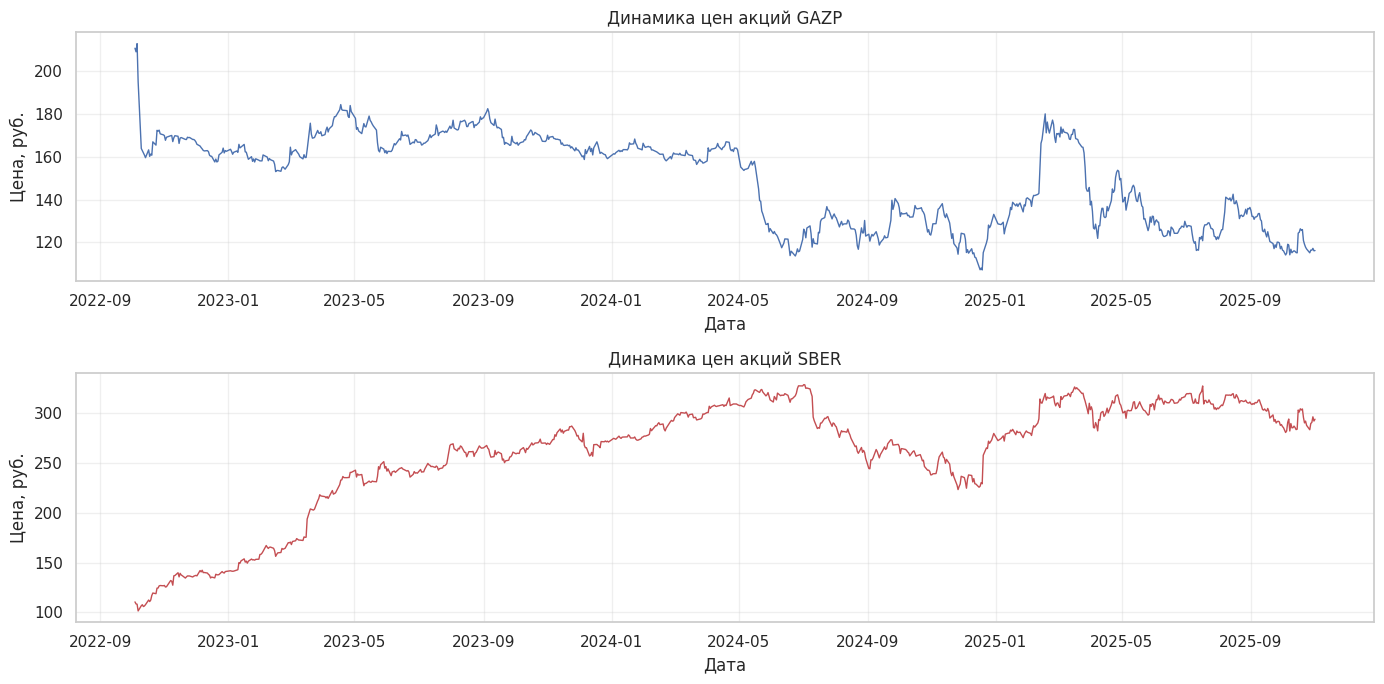

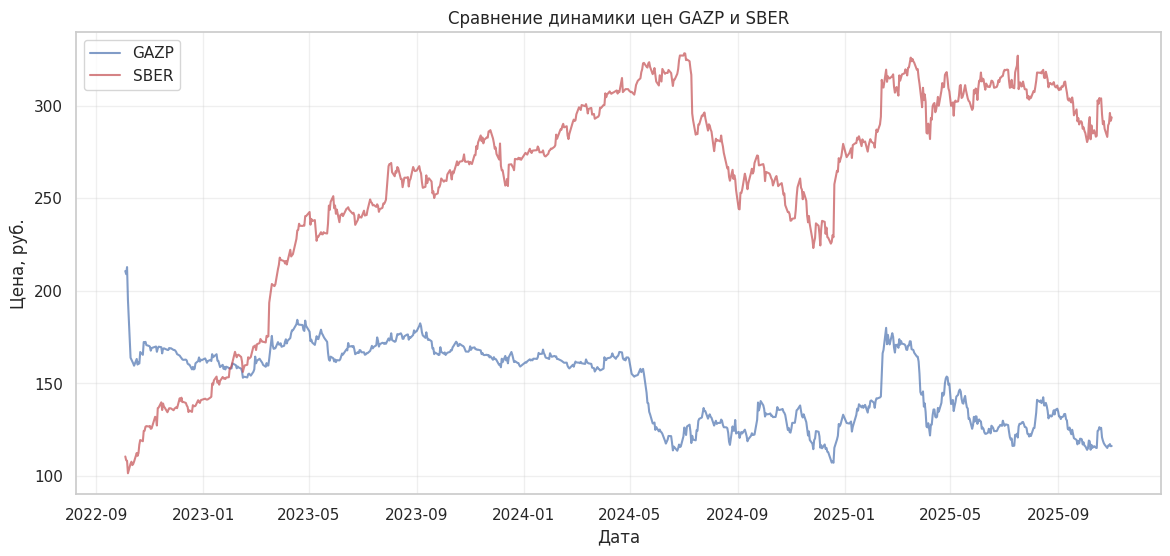

Период анализа: 2022-10-04 - 2025-11-01
Количество торговых дней: 838


In [28]:
# 13. График динамики цен
print("\n" + "="*60)
print("ДИНАМИКА ЦЕН АКЦИЙ")
print("="*60)

plt.figure(figsize=(14, 7))

# График цен GAZP
plt.subplot(2, 1, 1)
plt.plot(data_clean['date'], data_clean['GAZP_price'], 'b-', linewidth=1)
plt.title('Динамика цен акций GAZP')
plt.xlabel('Дата')
plt.ylabel('Цена, руб.')
plt.grid(True, alpha=0.3)

# График цен SBER
plt.subplot(2, 1, 2)
plt.plot(data_clean['date'], data_clean['SBER_price'], 'r-', linewidth=1)
plt.title('Динамика цен акций SBER')
plt.xlabel('Дата')
plt.ylabel('Цена, руб.')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сравнительный график
plt.figure(figsize=(14, 6))
plt.plot(data_clean['date'], data_clean['GAZP_price'], 'b-', label='GAZP', alpha=0.7)
plt.plot(data_clean['date'], data_clean['SBER_price'], 'r-', label='SBER', alpha=0.7)
plt.title('Сравнение динамики цен GAZP и SBER')
plt.xlabel('Дата')
plt.ylabel('Цена, руб.')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Период анализа: {data_clean['date'].min().date()} - {data_clean['date'].max().date()}")
print(f"Количество торговых дней: {len(data_clean)}")


АНАЛИЗ СВЯЗИ ЦЕНА-ОБЪЕМ


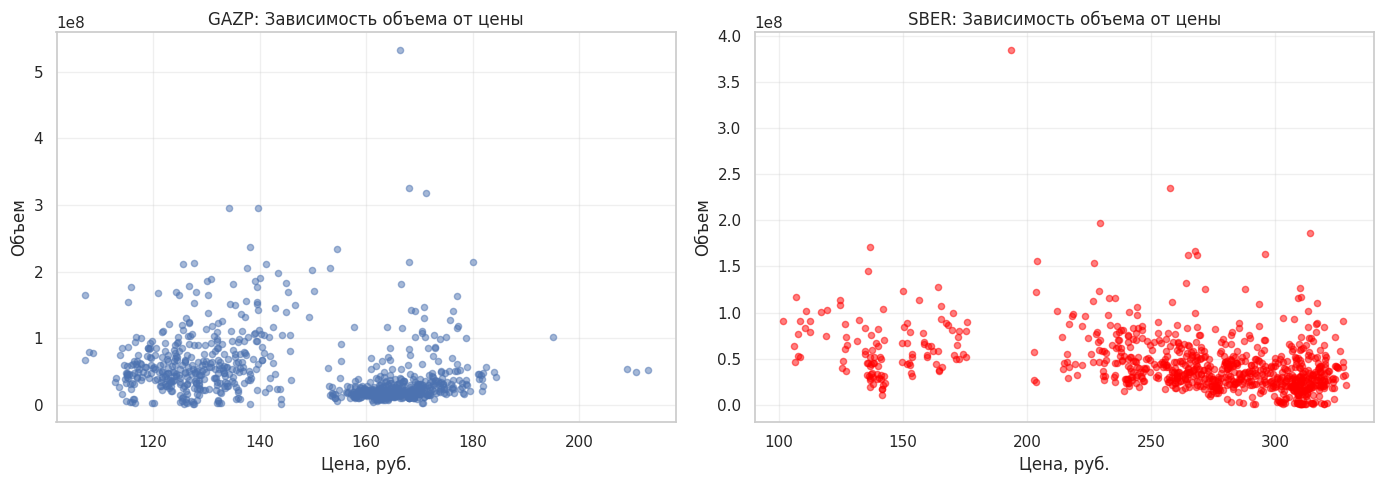


Корреляция цена-объем:
GAZP: -0.2323
SBER: -0.3613


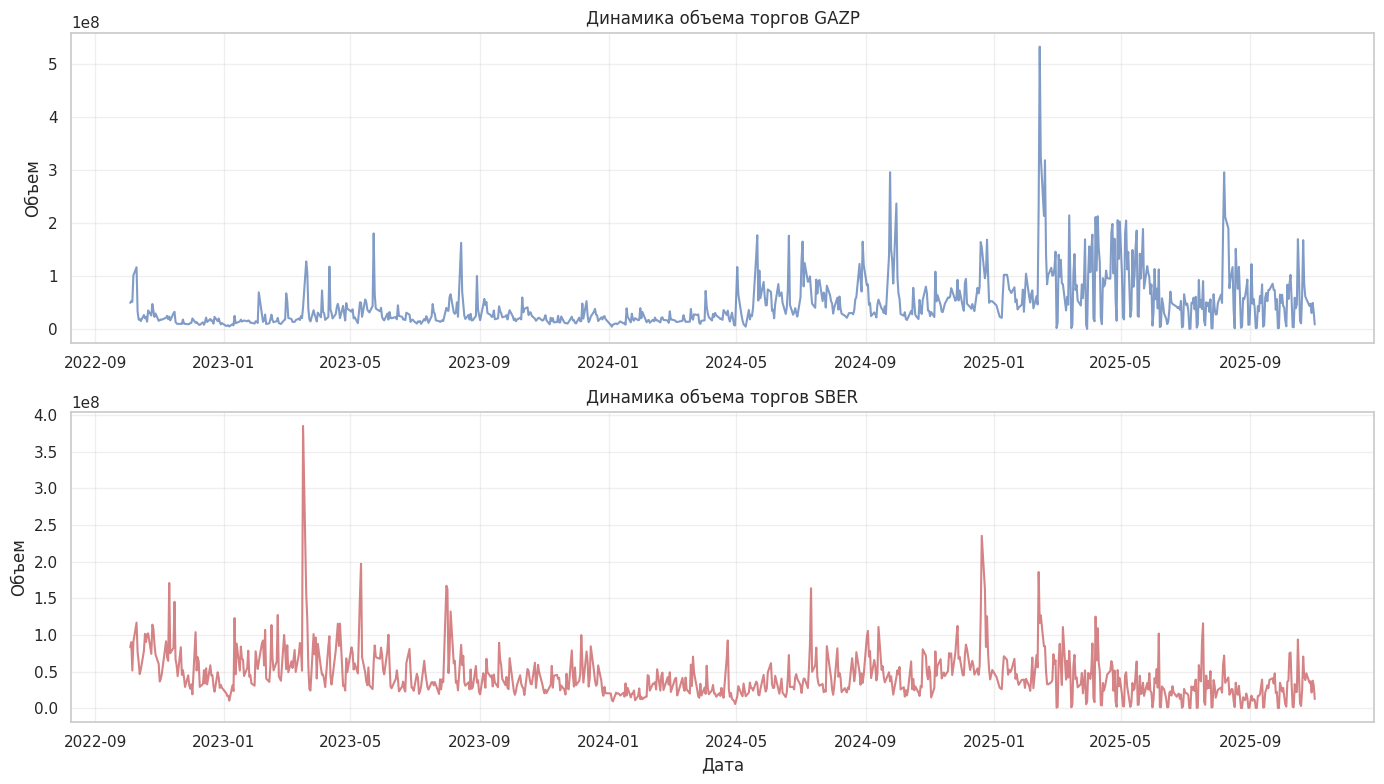

In [29]:
# 14. Анализ связи цена-объем
print("\n" + "="*60)
print("АНАЛИЗ СВЯЗИ ЦЕНА-ОБЪЕМ")
print("="*60)

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GAZP: цена vs объем
axes[0].scatter(data_clean['GAZP_price'], data_clean['GAZP_vol'],
                alpha=0.5, s=20)
axes[0].set_title('GAZP: Зависимость объема от цены')
axes[0].set_xlabel('Цена, руб.')
axes[0].set_ylabel('Объем')
axes[0].grid(True, alpha=0.3)

# SBER: цена vs объем
axes[1].scatter(data_clean['SBER_price'], data_clean['SBER_vol'],
                alpha=0.5, s=20, color='red')
axes[1].set_title('SBER: Зависимость объема от цены')
axes[1].set_xlabel('Цена, руб.')
axes[1].set_ylabel('Объем')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Рассчитываем корреляции
gazp_corr = data_clean['GAZP_price'].corr(data_clean['GAZP_vol'])
sber_corr = data_clean['SBER_price'].corr(data_clean['SBER_vol'])

print(f"\nКорреляция цена-объем:")
print(f"GAZP: {gazp_corr:.4f}")
print(f"SBER: {sber_corr:.4f}")

# Графики объема во времени
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Объемы GAZP
axes[0].plot(data_clean['date'], data_clean['GAZP_vol'], 'b-', alpha=0.7)
axes[0].set_title('Динамика объема торгов GAZP')
axes[0].set_ylabel('Объем')
axes[0].grid(True, alpha=0.3)

# Объемы SBER
axes[1].plot(data_clean['date'], data_clean['SBER_vol'], 'r-', alpha=0.7)
axes[1].set_title('Динамика объема торгов SBER')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Объем')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


АНАЛИЗ РАСПРЕДЕЛЕНИЯ ДОХОДНОСТЕЙ


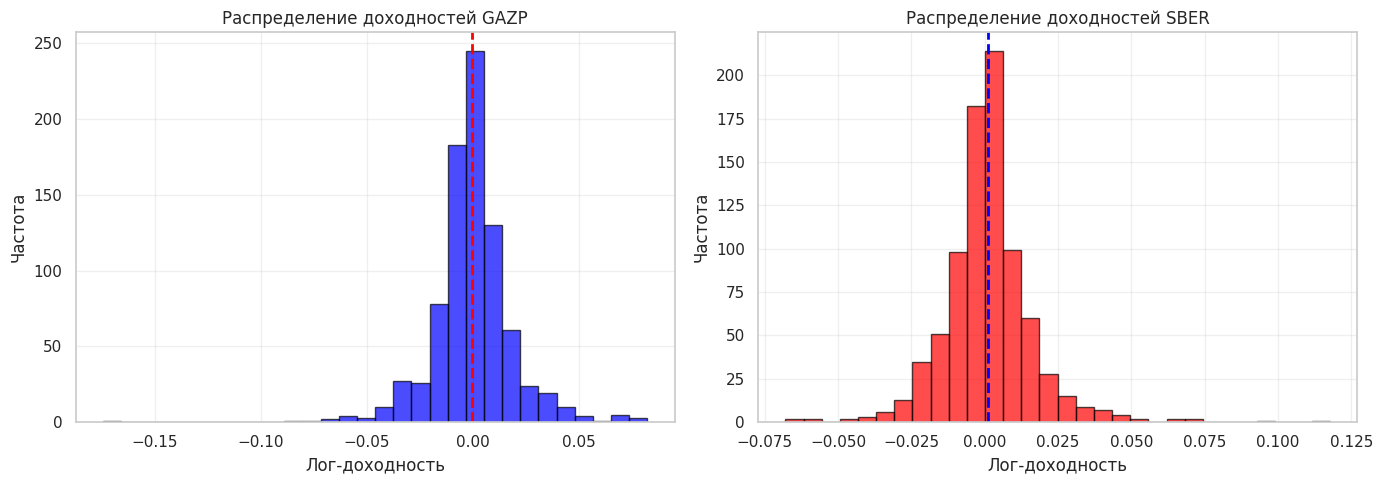

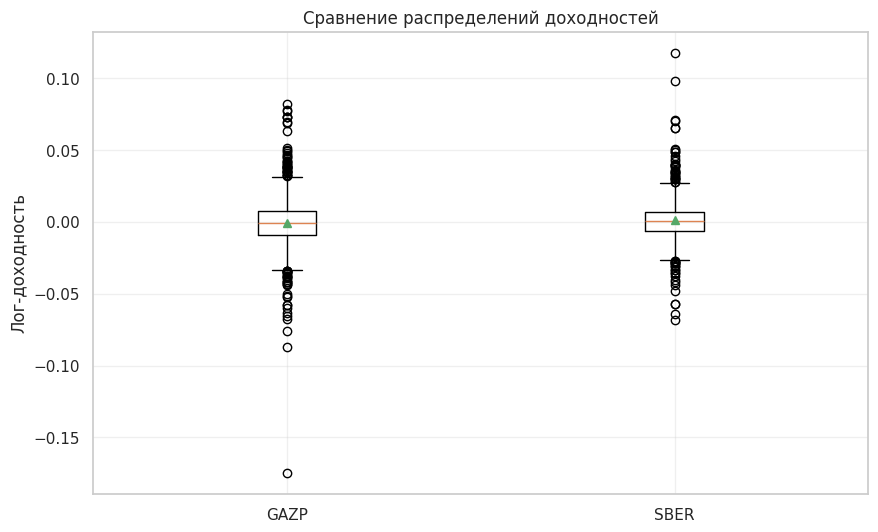


ХАРАКТЕРИСТИКИ РАСПРЕДЕЛЕНИЙ:
----------------------------------------

GAZP:
  Среднее: -0.000739
  Медиана: -0.000894
  Стандартное отклонение: 0.019373
  Асимметрия: -0.582
  Эксцесс: 10.311
  Выбросы (>3σ): 16 (1.9%)

SBER:
  Среднее: 0.001126
  Медиана: 0.000566
  Стандартное отклонение: 0.015553
  Асимметрия: 1.007
  Эксцесс: 8.025
  Выбросы (>3σ): 15 (1.8%)


In [30]:
# 15. Распределение доходностей
print("\n" + "="*60)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ДОХОДНОСТЕЙ")
print("="*60)

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма GAZP
axes[0].hist(data_clean['GAZP_log_return'], bins=30,
             color='blue', alpha=0.7, edgecolor='black')
axes[0].axvline(data_clean['GAZP_log_return'].mean(),
                color='red', linestyle='--', linewidth=2)
axes[0].set_title('Распределение доходностей GAZP')
axes[0].set_xlabel('Лог-доходность')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

# Гистограмма SBER
axes[1].hist(data_clean['SBER_log_return'], bins=30,
             color='red', alpha=0.7, edgecolor='black')
axes[1].axvline(data_clean['SBER_log_return'].mean(),
                color='blue', linestyle='--', linewidth=2)
axes[1].set_title('Распределение доходностей SBER')
axes[1].set_xlabel('Лог-доходность')
axes[1].set_ylabel('Частота')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Boxplot для сравнения
plt.figure(figsize=(10, 6))
box_data = [data_clean['GAZP_log_return'], data_clean['SBER_log_return']]
box_labels = ['GAZP', 'SBER']

plt.boxplot(box_data, labels=box_labels, showmeans=True)
plt.title('Сравнение распределений доходностей')
plt.ylabel('Лог-доходность')
plt.grid(True, alpha=0.3)
plt.show()

# Проверка на нормальность (упрощенная)
print("\nХАРАКТЕРИСТИКИ РАСПРЕДЕЛЕНИЙ:")
print("-"*40)

for asset in ['GAZP', 'SBER']:
    returns = data_clean[f'{asset}_log_return']
    print(f"\n{asset}:")
    print(f"  Среднее: {returns.mean():.6f}")
    print(f"  Медиана: {returns.median():.6f}")
    print(f"  Стандартное отклонение: {returns.std():.6f}")
    print(f"  Асимметрия: {skew(returns):.3f}")
    print(f"  Эксцесс: {kurtosis(returns):.3f}")

    # Проверка на выбросы (правило 3 сигм)
    outliers = returns[(returns.abs() > 3 * returns.std())]
    print(f"  Выбросы (>3σ): {len(outliers)} ({len(outliers)/len(returns)*100:.1f}%)")


КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
КОРРЕЛЯЦИОННАЯ МАТРИЦА:
                 GAZP_price  SBER_price  GAZP_log_return  SBER_log_return  \
GAZP_price            1.000      -0.413            0.046            0.084   
SBER_price           -0.413       1.000            0.046           -0.061   
GAZP_log_return       0.046       0.046            1.000            0.499   
SBER_log_return       0.084      -0.061            0.499            1.000   
GAZP_vol             -0.232       0.301            0.088           -0.011   
SBER_vol              0.152      -0.361            0.083            0.233   

                 GAZP_vol  SBER_vol  
GAZP_price         -0.232     0.152  
SBER_price          0.301    -0.361  
GAZP_log_return     0.088     0.083  
SBER_log_return    -0.011     0.233  
GAZP_vol            1.000     0.283  
SBER_vol            0.283     1.000  


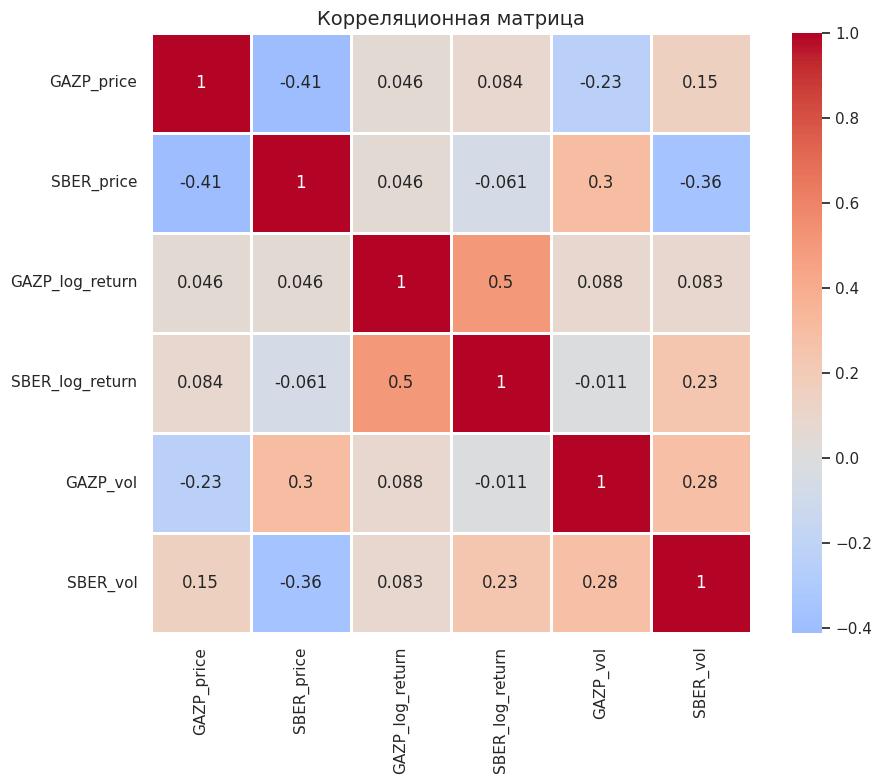


КЛЮЧЕВЫЕ КОРРЕЛЯЦИИ:
----------------------------------------
Цены GAZP и SBER: -0.4131
Доходности GAZP и SBER: 0.4991
Объемы GAZP и SBER: 0.2827

Корреляция цена-объем:
GAZP: -0.2323
SBER: -0.3613


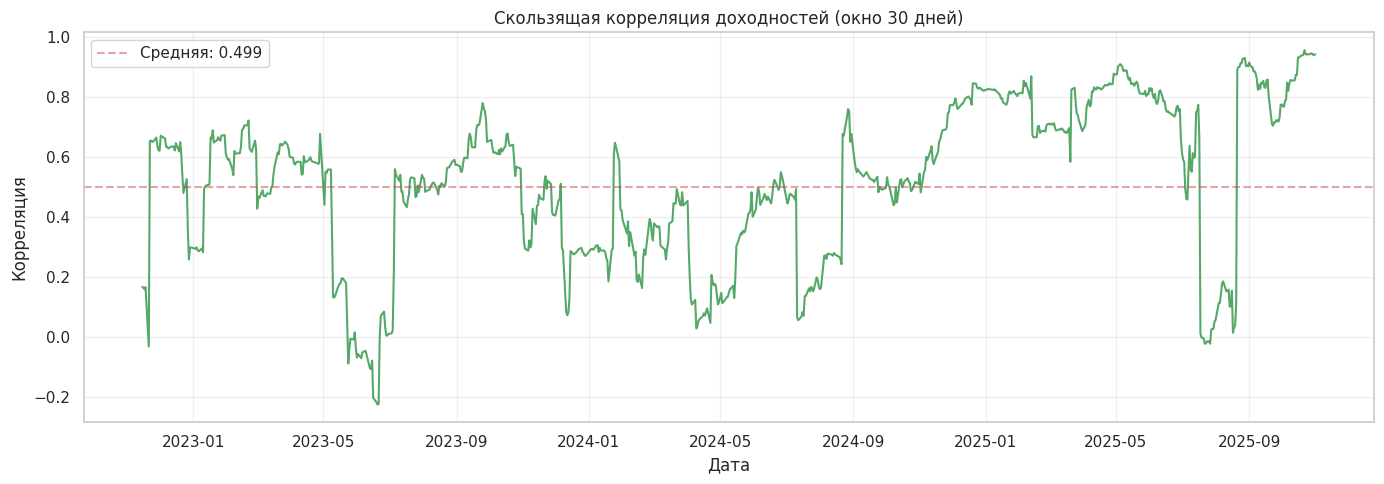


Анализ скользящей корреляции:
Минимальная корреляция: -0.2252
Максимальная корреляция: 0.9555
Средняя корреляция: 0.5265


In [31]:
# 16. Корреляционный анализ
print("\n" + "="*60)
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*60)

# Выбираем ключевые переменные для анализа
corr_vars = ['GAZP_price', 'SBER_price',
             'GAZP_log_return', 'SBER_log_return',
             'GAZP_vol', 'SBER_vol']

# Создаем корреляционную матрицу
corr_matrix = data_clean[corr_vars].corr()

print("КОРРЕЛЯЦИОННАЯ МАТРИЦА:")
print(corr_matrix.round(3))

# Визуализация тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Корреляционная матрица', fontsize=14)
plt.tight_layout()
plt.show()

# Анализ основных корреляций
print("\nКЛЮЧЕВЫЕ КОРРЕЛЯЦИИ:")
print("-"*40)

# Корреляция цен
price_corr = corr_matrix.loc['GAZP_price', 'SBER_price']
print(f"Цены GAZP и SBER: {price_corr:.4f}")

# Корреляция доходностей
return_corr = corr_matrix.loc['GAZP_log_return', 'SBER_log_return']
print(f"Доходности GAZP и SBER: {return_corr:.4f}")

# Корреляция объемов
vol_corr = corr_matrix.loc['GAZP_vol', 'SBER_vol']
print(f"Объемы GAZP и SBER: {vol_corr:.4f}")

# Корреляция цена-объем внутри активов
gazp_price_vol = corr_matrix.loc['GAZP_price', 'GAZP_vol']
sber_price_vol = corr_matrix.loc['SBER_price', 'SBER_vol']
print(f"\nКорреляция цена-объем:")
print(f"GAZP: {gazp_price_vol:.4f}")
print(f"SBER: {sber_price_vol:.4f}")

# Динамика корреляции доходностей (скользящее окно)
window_size = 30  # 30 торговых дней
rolling_corr = data_clean['GAZP_log_return'].rolling(window=window_size).corr(data_clean['SBER_log_return'])

plt.figure(figsize=(14, 5))
plt.plot(data_clean['date'], rolling_corr, 'g-', linewidth=1.5)
plt.axhline(y=return_corr, color='r', linestyle='--', alpha=0.5, label=f'Средняя: {return_corr:.3f}')
plt.title(f'Скользящая корреляция доходностей (окно {window_size} дней)')
plt.xlabel('Дата')
plt.ylabel('Корреляция')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nАнализ скользящей корреляции:")
print(f"Минимальная корреляция: {rolling_corr.min():.4f}")
print(f"Максимальная корреляция: {rolling_corr.max():.4f}")
print(f"Средняя корреляция: {rolling_corr.mean():.4f}")


АНАЛИЗ ВОЛАТИЛЬНОСТИ


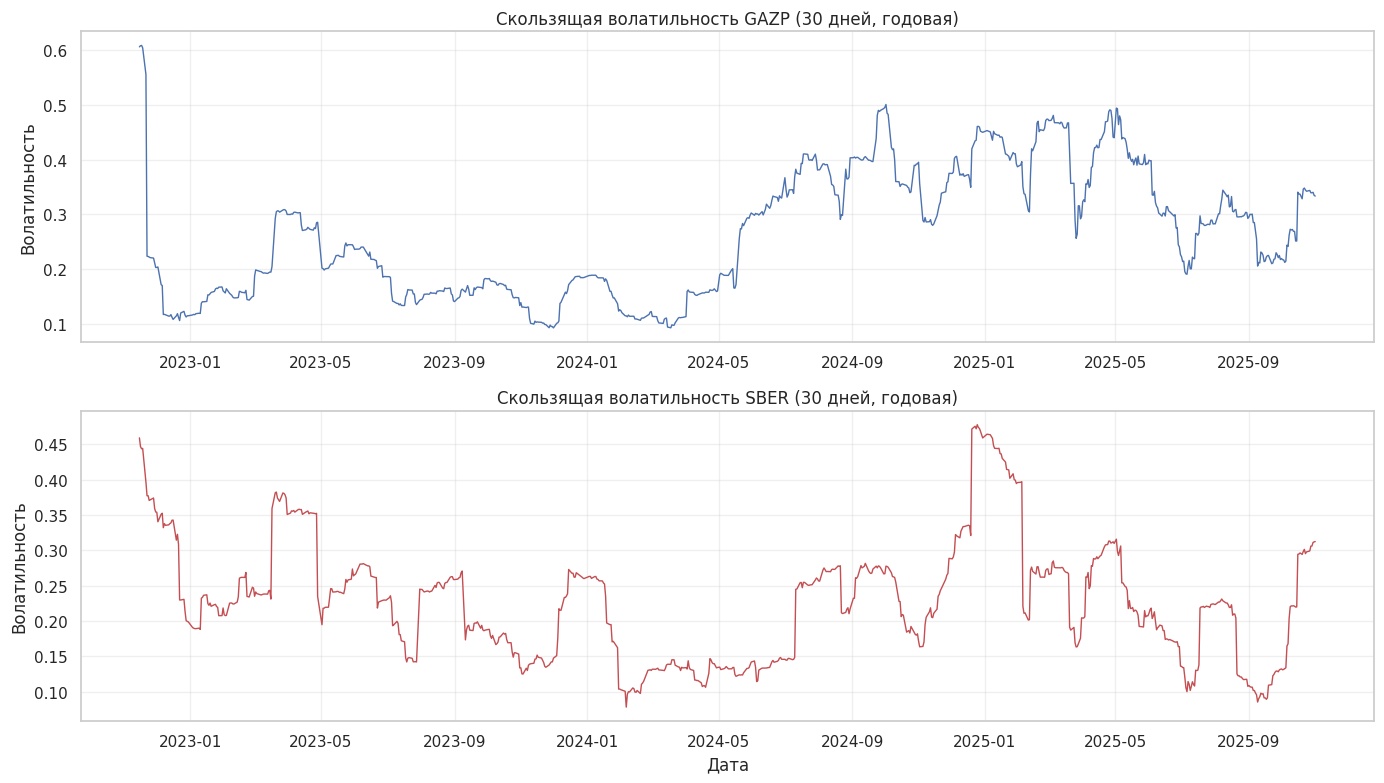

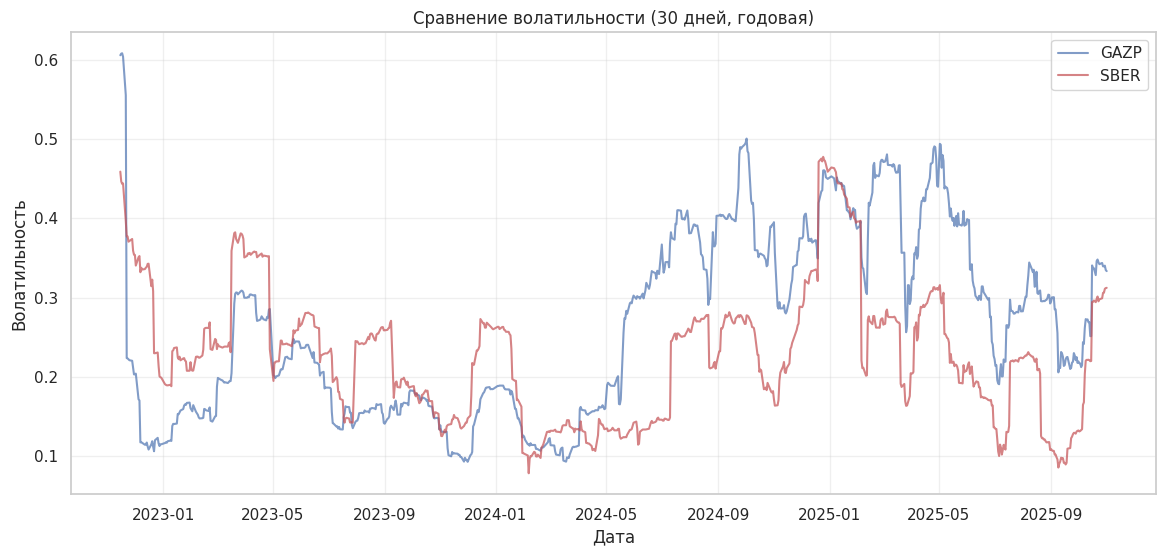


СТАТИСТИКА ВОЛАТИЛЬНОСТИ:
----------------------------------------
Показатель  GAZP  SBER
   Средняя 0.267 0.225
   Медиана 0.270 0.221
  Максимум 0.608 0.478
   Минимум 0.093 0.078
   Текущая 0.333 0.312


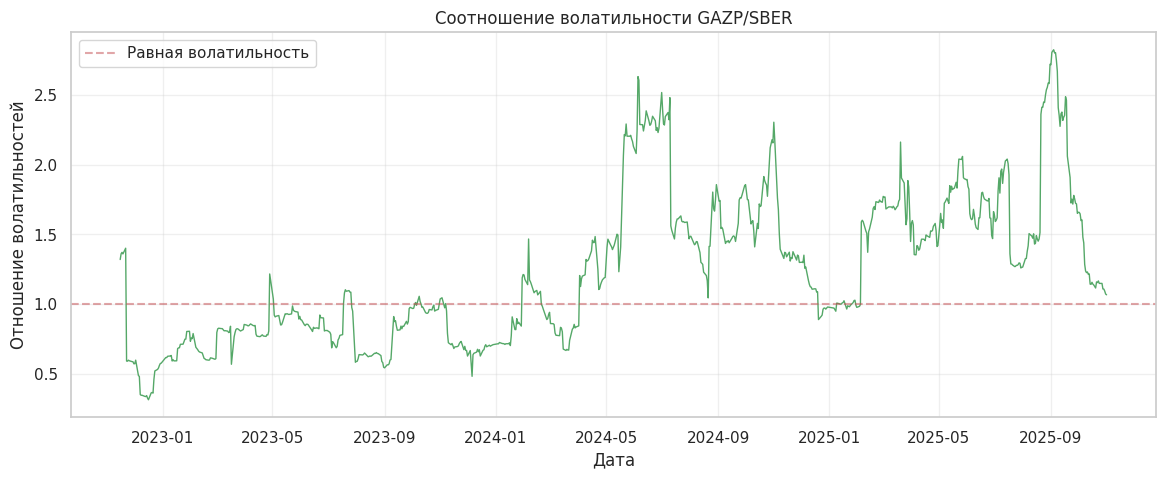


Среднее отношение волатильностей GAZP/SBER: 1.265
GAZP в среднем выше по волатильности, чем SBER


In [32]:
# 17. Анализ волатильности
print("\n" + "="*60)
print("АНАЛИЗ ВОЛАТИЛЬНОСТИ")
print("="*60)

# Рассчитываем скользящую волатильность (30 дней)
window = 30
data_clean['GAZP_volatility'] = data_clean['GAZP_log_return'].rolling(window=window).std() * np.sqrt(252)
data_clean['SBER_volatility'] = data_clean['SBER_log_return'].rolling(window=window).std() * np.sqrt(252)

# Графики волатильности
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Волатильность GAZP
axes[0].plot(data_clean['date'], data_clean['GAZP_volatility'], 'b-', linewidth=1)
axes[0].set_title(f'Скользящая волатильность GAZP ({window} дней, годовая)')
axes[0].set_ylabel('Волатильность')
axes[0].grid(True, alpha=0.3)

# Волатильность SBER
axes[1].plot(data_clean['date'], data_clean['SBER_volatility'], 'r-', linewidth=1)
axes[1].set_title(f'Скользящая волатильность SBER ({window} дней, годовая)')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Волатильность')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сравнительный график
plt.figure(figsize=(14, 6))
plt.plot(data_clean['date'], data_clean['GAZP_volatility'], 'b-', label='GAZP', alpha=0.7)
plt.plot(data_clean['date'], data_clean['SBER_volatility'], 'r-', label='SBER', alpha=0.7)
plt.title(f'Сравнение волатильности ({window} дней, годовая)')
plt.xlabel('Дата')
plt.ylabel('Волатильность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Статистика волатильности
print("\nСТАТИСТИКА ВОЛАТИЛЬНОСТИ:")
print("-"*40)

vol_stats = pd.DataFrame({
    'Показатель': ['Средняя', 'Медиана', 'Максимум', 'Минимум', 'Текущая'],
    'GAZP': [
        data_clean['GAZP_volatility'].mean(),
        data_clean['GAZP_volatility'].median(),
        data_clean['GAZP_volatility'].max(),
        data_clean['GAZP_volatility'].min(),
        data_clean['GAZP_volatility'].iloc[-1]
    ],
    'SBER': [
        data_clean['SBER_volatility'].mean(),
        data_clean['SBER_volatility'].median(),
        data_clean['SBER_volatility'].max(),
        data_clean['SBER_volatility'].min(),
        data_clean['SBER_volatility'].iloc[-1]
    ]
})

print(vol_stats.round(3).to_string(index=False))

# Соотношение волатильностей
vol_ratio = data_clean['GAZP_volatility'] / data_clean['SBER_volatility']

plt.figure(figsize=(14, 5))
plt.plot(data_clean['date'], vol_ratio, 'g-', linewidth=1)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Равная волатильность')
plt.title('Соотношение волатильности GAZP/SBER')
plt.xlabel('Дата')
plt.ylabel('Отношение волатильностей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nСреднее отношение волатильностей GAZP/SBER: {vol_ratio.mean():.3f}")
print(f"GAZP в среднем {'выше' if vol_ratio.mean() > 1 else 'ниже'} по волатильности, чем SBER")


АНАЛИЗ ТРЕНДОВ И СКОЛЬЗЯЩИХ СРЕДНИХ


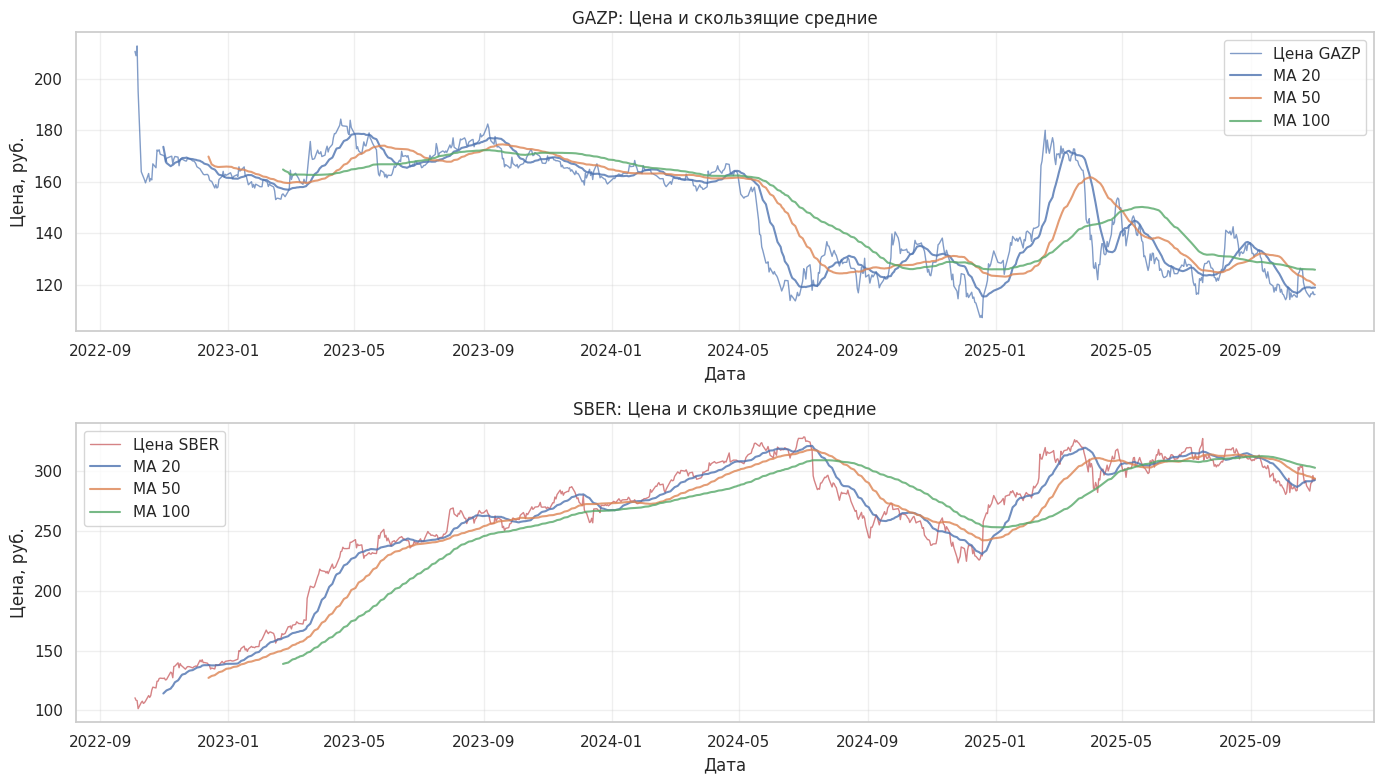


АНАЛИЗ ТРЕНДОВЫХ СИГНАЛОВ:
----------------------------------------

ТЕКУЩИЕ ТРЕНДЫ (20 vs 50 дней):
GAZP: Медвежий
  Бычьих дней: 306 (41.5%)
  Медвежьих дней: 432 (58.5%)
SBER: Медвежий
  Бычьих дней: 475 (64.4%)
  Медвежьих дней: 263 (35.6%)

ДОХОДНОСТЬ В РАЗНЫЕ ТРЕНДОВЫЕ ПЕРИОДЫ:
----------------------------------------

GAZP:
  Бычий тренд: 306 дней, сред. доходность: -0.084%
  Медвежий тренд: 432 дней, сред. доходность: -0.008%

SBER:
  Бычий тренд: 475 дней, сред. доходность: 0.119%
  Медвежий тренд: 263 дней, сред. доходность: 0.009%


In [33]:
# 18. Анализ трендов и скользящих средних
print("\n" + "="*60)
print("АНАЛИЗ ТРЕНДОВ И СКОЛЬЗЯЩИХ СРЕДНИХ")
print("="*60)

# Рассчитываем скользящие средние
windows = [20, 50, 100]  # Короткая, средняя, долгая

for window in windows:
    data_clean[f'GAZP_MA_{window}'] = data_clean['GAZP_price'].rolling(window=window).mean()
    data_clean[f'SBER_MA_{window}'] = data_clean['SBER_price'].rolling(window=window).mean()

# Графики для GAZP
plt.figure(figsize=(14, 8))

# Цена и скользящие средние GAZP
plt.subplot(2, 1, 1)
plt.plot(data_clean['date'], data_clean['GAZP_price'], 'b-', label='Цена GAZP', alpha=0.7, linewidth=1)
for window in windows:
    plt.plot(data_clean['date'], data_clean[f'GAZP_MA_{window}'],
             label=f'MA {window}', alpha=0.8)
plt.title('GAZP: Цена и скользящие средние')
plt.xlabel('Дата')
plt.ylabel('Цена, руб.')
plt.legend()
plt.grid(True, alpha=0.3)

# Цена и скользящие средние SBER
plt.subplot(2, 1, 2)
plt.plot(data_clean['date'], data_clean['SBER_price'], 'r-', label='Цена SBER', alpha=0.7, linewidth=1)
for window in windows:
    plt.plot(data_clean['date'], data_clean[f'SBER_MA_{window}'],
             label=f'MA {window}', alpha=0.8)
plt.title('SBER: Цена и скользящие средние')
plt.xlabel('Дата')
plt.ylabel('Цена, руб.')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ трендовых сигналов
print("\nАНАЛИЗ ТРЕНДОВЫХ СИГНАЛОВ:")
print("-"*40)

def analyze_trends(price_col, ma_short, ma_long):
    """Анализирует трендовые сигналы"""
    signals = []

    for i in range(len(data_clean)):
        if i < max(windows):
            signals.append(0)
            continue

        # Золотой крест (короткая MA выше длинной)
        if data_clean[ma_short].iloc[i] > data_clean[ma_long].iloc[i]:
            signals.append(1)  # Бычий тренд
        # Мертвый крест (короткая MA ниже длинной)
        elif data_clean[ma_short].iloc[i] < data_clean[ma_long].iloc[i]:
            signals.append(-1)  # Медвежий тренд
        else:
            signals.append(0)  # Нейтрально

    return signals

# Применяем для GAZP (20 vs 50 дней)
data_clean['GAZP_trend_20_50'] = analyze_trends('GAZP_price', 'GAZP_MA_20', 'GAZP_MA_50')
data_clean['SBER_trend_20_50'] = analyze_trends('SBER_price', 'SBER_MA_20', 'SBER_MA_50')

# Анализ текущего тренда
print("\nТЕКУЩИЕ ТРЕНДЫ (20 vs 50 дней):")

for asset in ['GAZP', 'SBER']:
    current_trend = data_clean[f'{asset}_trend_20_50'].iloc[-1]
    trend_text = {1: 'Бычий', -1: 'Медвежий', 0: 'Нейтральный'}

    print(f"{asset}: {trend_text[current_trend]}")

    # Статистика трендов
    trend_counts = data_clean[f'{asset}_trend_20_50'].value_counts()
    total_days = len(data_clean[data_clean[f'{asset}_trend_20_50'] != 0])

    print(f"  Бычьих дней: {trend_counts.get(1, 0)} ({trend_counts.get(1, 0)/total_days*100:.1f}%)")
    print(f"  Медвежьих дней: {trend_counts.get(-1, 0)} ({trend_counts.get(-1, 0)/total_days*100:.1f}%)")

# Доходность в разные трендовые периоды
print("\nДОХОДНОСТЬ В РАЗНЫЕ ТРЕНДОВЫЕ ПЕРИОДЫ:")
print("-"*40)

for asset in ['GAZP', 'SBER']:
    trend_col = f'{asset}_trend_20_50'
    return_col = f'{asset}_log_return'

    bullish_returns = data_clean[data_clean[trend_col] == 1][return_col]
    bearish_returns = data_clean[data_clean[trend_col] == -1][return_col]

    print(f"\n{asset}:")
    print(f"  Бычий тренд: {len(bullish_returns)} дней, сред. доходность: {bullish_returns.mean()*100:.3f}%")
    print(f"  Медвежий тренд: {len(bearish_returns)} дней, сред. доходность: {bearish_returns.mean()*100:.3f}%")


АНАЛИЗ РИСКА (VaR, CVaR)

РАСЧЕТ VALUE AT RISK (VaR):
----------------------------------------

GAZP:
  Уровень доверия 95.0%:
    Исторический VaR: 3.060%
    Параметрический VaR: 3.187%
  Уровень доверия 99.0%:
    Исторический VaR: 5.565%
    Параметрический VaR: 4.507%

SBER:
  Уровень доверия 95.0%:
    Исторический VaR: 2.075%
    Параметрический VaR: 2.558%
  Уровень доверия 99.0%:
    Исторический VaR: 3.674%
    Параметрический VaR: 3.618%

РАСЧЕТ CONDITIONAL VaR (CVaR):
----------------------------------------

GAZP:
  Уровень доверия 95.0%:
    CVaR: 4.626%
    Количество наблюдений в хвосте: 42
  Уровень доверия 99.0%:
    CVaR: 7.880%
    Количество наблюдений в хвосте: 9

SBER:
  Уровень доверия 95.0%:
    CVaR: 3.157%
    Количество наблюдений в хвосте: 42
  Уровень доверия 99.0%:
    CVaR: 5.091%
    Количество наблюдений в хвосте: 9


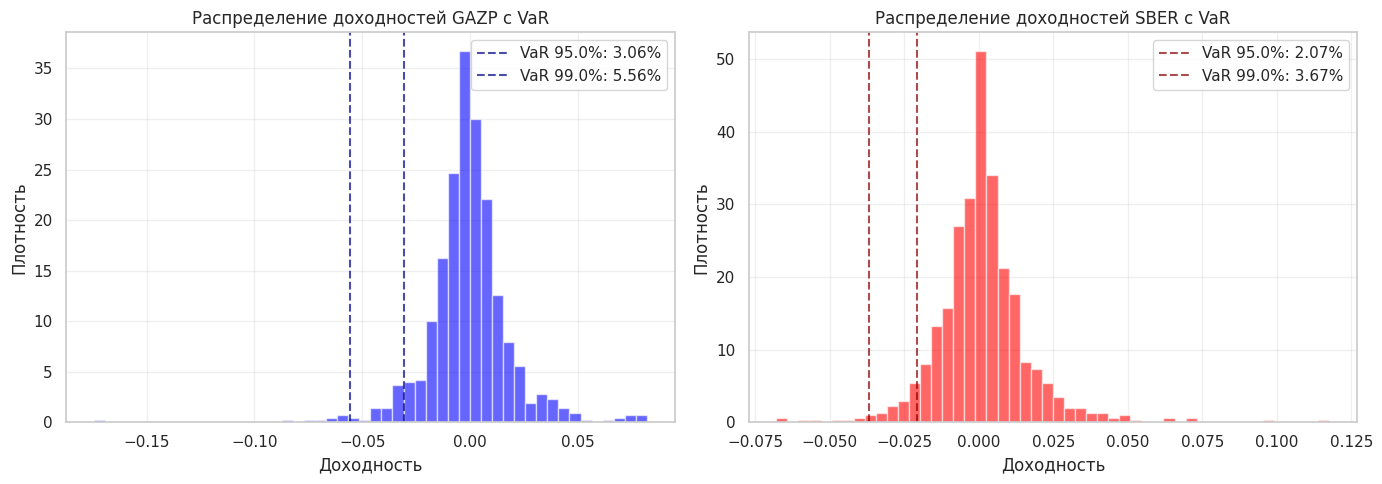


АНАЛИЗ МАКСИМАЛЬНЫХ ПРОСАДОК:
----------------------------------------

GAZP:
  Максимальная просадка: -49.66%
  Дата максимальной просадки: 2024-12-20
  Кумулятивная доходность: -44.86%

SBER:
  Максимальная просадка: -32.04%
  Дата максимальной просадки: 2024-11-27
  Кумулятивная доходность: 165.67%


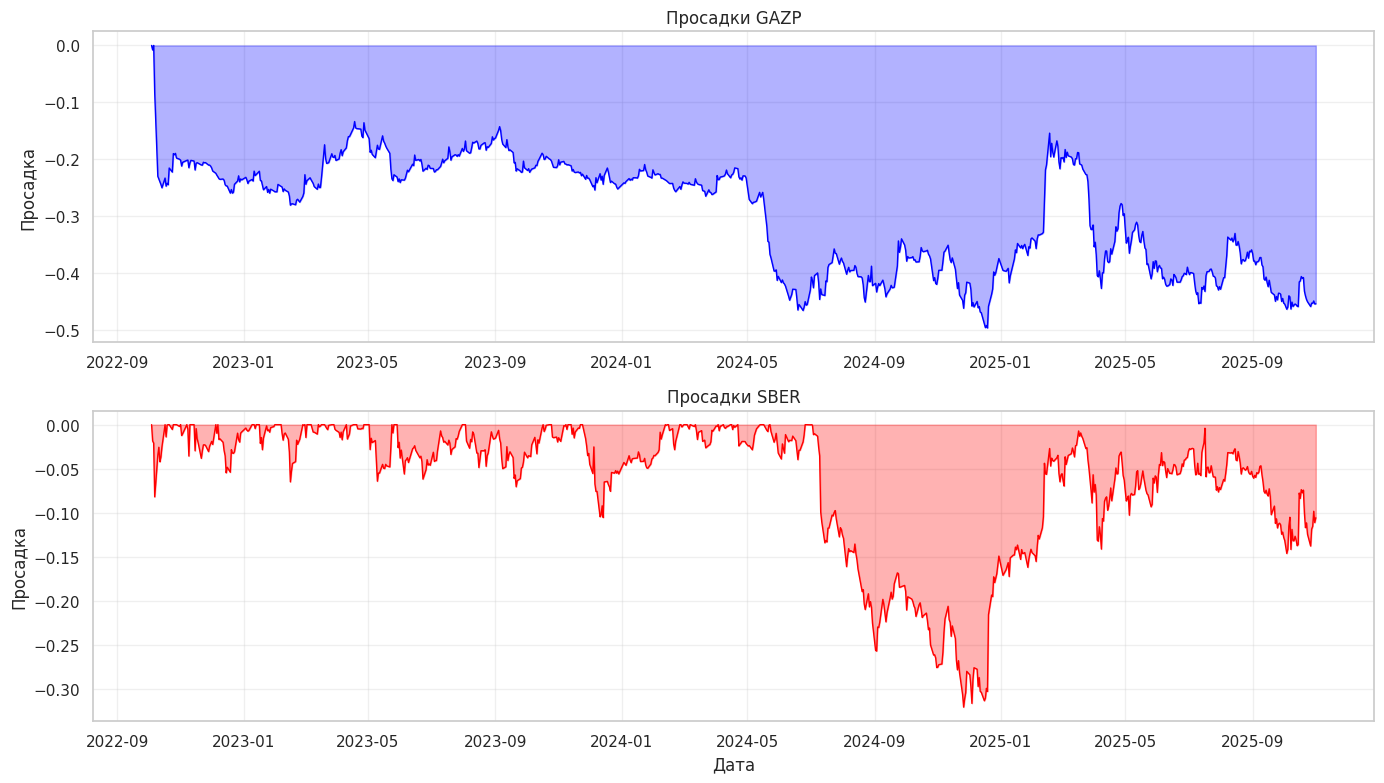

In [34]:
# 19. Анализ риска (VaR, CVaR)
print("\n" + "="*60)
print("АНАЛИЗ РИСКА (VaR, CVaR)")
print("="*60)

# Уровни доверия для VaR
confidence_levels = [0.95, 0.99]

print("\nРАСЧЕТ VALUE AT RISK (VaR):")
print("-"*40)

for asset in ['GAZP', 'SBER']:
    returns = data_clean[f'{asset}_log_return']

    print(f"\n{asset}:")
    for cl in confidence_levels:
        # Исторический VaR
        historical_var = -np.percentile(returns, (1-cl)*100)

        # Параметрический VaR (нормальное распределение)
        from scipy.stats import norm
        parametric_var = -norm.ppf(1-cl) * returns.std()

        print(f"  Уровень доверия {cl*100}%:")
        print(f"    Исторический VaR: {historical_var*100:.3f}%")
        print(f"    Параметрический VaR: {parametric_var*100:.3f}%")

print("\nРАСЧЕТ CONDITIONAL VaR (CVaR):")
print("-"*40)

for asset in ['GAZP', 'SBER']:
    returns = data_clean[f'{asset}_log_return']

    print(f"\n{asset}:")
    for cl in confidence_levels:
        # CVaR как среднее убытков ниже VaR
        var_threshold = -np.percentile(returns, (1-cl)*100)
        cvar_losses = returns[returns < -var_threshold]
        cvar = -cvar_losses.mean() if len(cvar_losses) > 0 else 0

        print(f"  Уровень доверия {cl*100}%:")
        print(f"    CVaR: {cvar*100:.3f}%")
        print(f"    Количество наблюдений в хвосте: {len(cvar_losses)}")

# Визуализация распределения и VaR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, asset in enumerate(['GAZP', 'SBER']):
    returns = data_clean[f'{asset}_log_return']

    # Гистограмма с VaR
    axes[idx].hist(returns, bins=50, density=True, alpha=0.6, color=['blue', 'red'][idx])

    # Отметки VaR
    for cl in confidence_levels:
        var = -np.percentile(returns, (1-cl)*100)
        axes[idx].axvline(-var, color=['darkblue', 'darkred'][idx],
                         linestyle='--', alpha=0.7,
                         label=f'VaR {cl*100}%: {var*100:.2f}%')

    axes[idx].set_title(f'Распределение доходностей {asset} с VaR')
    axes[idx].set_xlabel('Доходность')
    axes[idx].set_ylabel('Плотность')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Максимальные просадки (Drawdown)
print("\nАНАЛИЗ МАКСИМАЛЬНЫХ ПРОСАДОК:")
print("-"*40)

for asset in ['GAZP', 'SBER']:
    price = data_clean[f'{asset}_price']

    # Рассчитываем кумулятивную доходность
    cumulative_return = (price / price.iloc[0] - 1)

    # Рассчитываем просадки
    running_max = cumulative_return.expanding().max()
    drawdown = (cumulative_return - running_max) / (1 + running_max)
    max_drawdown = drawdown.min()
    max_dd_date = data_clean['date'].iloc[drawdown.idxmin()]

    print(f"\n{asset}:")
    print(f"  Максимальная просадка: {max_drawdown*100:.2f}%")
    print(f"  Дата максимальной просадки: {max_dd_date.date()}")
    print(f"  Кумулятивная доходность: {cumulative_return.iloc[-1]*100:.2f}%")

# График просадок
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, asset in enumerate(['GAZP', 'SBER']):
    price = data_clean[f'{asset}_price']
    cumulative_return = (price / price.iloc[0] - 1)
    running_max = cumulative_return.expanding().max()
    drawdown = (cumulative_return - running_max) / (1 + running_max)

    axes[idx].fill_between(data_clean['date'], drawdown, 0,
                          alpha=0.3, color=['blue', 'red'][idx])
    axes[idx].plot(data_clean['date'], drawdown,
                  color=['blue', 'red'][idx], linewidth=1)
    axes[idx].set_title(f'Просадки {asset}')
    axes[idx].set_ylabel('Просадка')
    axes[idx].grid(True, alpha=0.3)

axes[1].set_xlabel('Дата')
plt.tight_layout()
plt.show()


ОПТИМИЗАЦИЯ ПОРТФЕЛЯ

ОЖИДАЕМЫЕ ДОХОДНОСТИ (годовые):
GAZP: -18.62%
SBER: 28.37%

КОВАРИАЦИОННАЯ МАТРИЦА (годовая):
                 GAZP_log_return  SBER_log_return
GAZP_log_return         0.094582         0.037898
SBER_log_return         0.037898         0.060961

ОПТИМАЛЬНЫЕ ПОРТФЕЛИ:
----------------------------------------

МАКСИМАЛЬНЫЙ КОЭФФИЦИЕНТ ШАРПА:
Доходность: 28.37%
Риск: 24.69%
Коэффициент Шарпа: 1.149
Вес GAZP: 0.0%
Вес SBER: 100.0%

МИНИМАЛЬНЫЙ РИСК:
Доходность: 14.78%
Риск: 23.30%
Коэффициент Шарпа: 0.634
Вес GAZP: 28.9%
Вес SBER: 71.1%


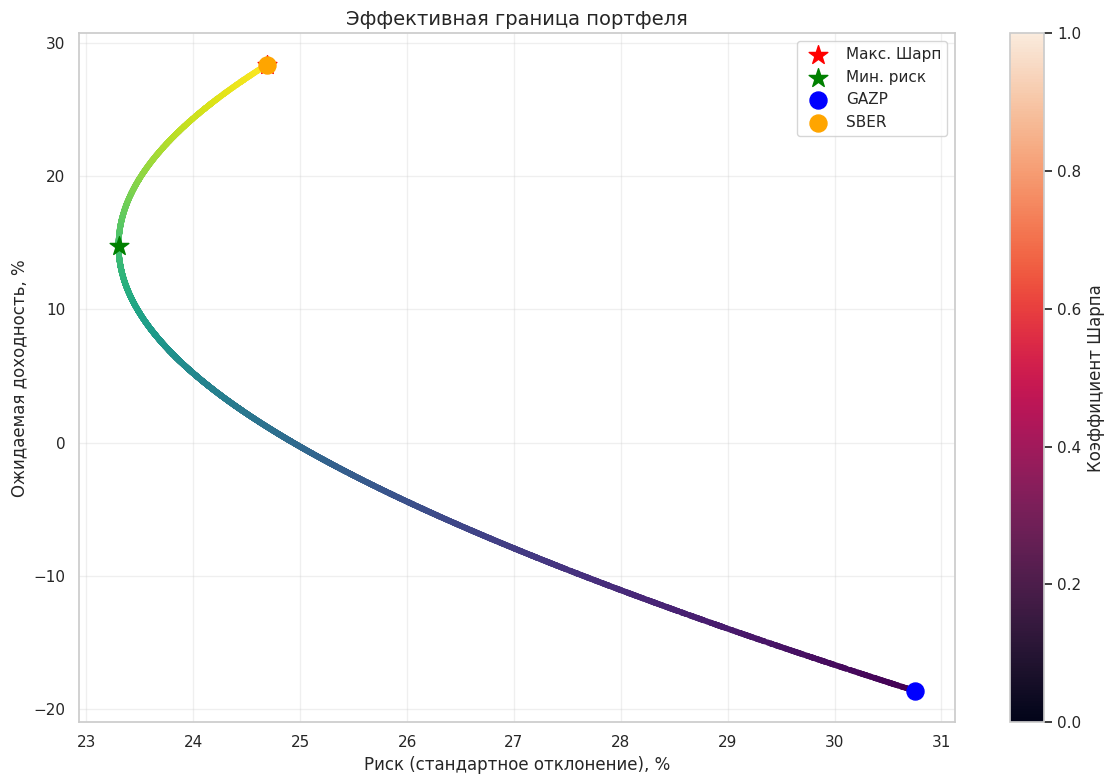


АНАЛИЗ ДИВЕРСИФИКАЦИИ:
----------------------------------------
Корреляция доходностей: 0.4991

ПОРТФЕЛЬ 50/50:
Доходность: 4.87%
Риск: 24.05%
Коэффициент Шарпа: 0.203

Сравнение с отдельными активами:
GAZP: Снижение риска при диверсификации: 21.8%
SBER: Снижение риска при диверсификации: 2.6%


In [36]:
# 20. Оптимизация портфеля
print("\n" + "="*60)
print("ОПТИМИЗАЦИЯ ПОРТФЕЛЯ")
print("="*60)

# Рассчитываем ожидаемые доходности и ковариационную матрицу
returns = data_clean[['GAZP_log_return', 'SBER_log_return']]
expected_returns = returns.mean() * 252  # Годовые доходности
cov_matrix = returns.cov() * 252  # Годовая ковариационная матрица

print("\nОЖИДАЕМЫЕ ДОХОДНОСТИ (годовые):")
print(f"GAZP: {expected_returns['GAZP_log_return']*100:.2f}%")
print(f"SBER: {expected_returns['SBER_log_return']*100:.2f}%")

print("\nКОВАРИАЦИОННАЯ МАТРИЦА (годовая):")
print(cov_matrix)

# Функция для расчета параметров портфеля
def portfolio_performance(weights):
    """Рассчитывает доходность и риск портфеля"""
    weights_array = np.array(weights)
    port_return = np.sum(weights_array * expected_returns.values)
    port_volatility = np.sqrt(np.dot(weights_array.T, np.dot(cov_matrix.values, weights_array)))
    sharpe_ratio = port_return / port_volatility if port_volatility != 0 else 0
    return port_return, port_volatility, sharpe_ratio

# Генерируем случайные портфели
np.random.seed(42)
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    # Генерируем случайные веса
    w = np.random.random(2)
    w = w / np.sum(w)  # Нормализуем к сумме 1

    # Рассчитываем параметры портфеля
    port_return, port_volatility, sharpe_ratio = portfolio_performance(w)

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe_ratio
    weights_record.append(w)

# Конвертируем в DataFrame
portfolios = pd.DataFrame({
    'Доходность': results[0],
    'Риск': results[1],
    'Коэффициент Шарпа': results[2],
    'Вес GAZP': [w[0] for w in weights_record],
    'Вес SBER': [w[1] for w in weights_record]
})

# Находим оптимальные портфели
max_sharpe_idx = portfolios['Коэффициент Шарпа'].idxmax()
min_risk_idx = portfolios['Риск'].idxmin()

max_sharpe_port = portfolios.loc[max_sharpe_idx]
min_risk_port = portfolios.loc[min_risk_idx]

print("\nОПТИМАЛЬНЫЕ ПОРТФЕЛИ:")
print("-"*40)

print(f"\nМАКСИМАЛЬНЫЙ КОЭФФИЦИЕНТ ШАРПА:")
print(f"Доходность: {max_sharpe_port['Доходность']*100:.2f}%")
print(f"Риск: {max_sharpe_port['Риск']*100:.2f}%")
print(f"Коэффициент Шарпа: {max_sharpe_port['Коэффициент Шарпа']:.3f}")
print(f"Вес GAZP: {max_sharpe_port['Вес GAZP']*100:.1f}%")
print(f"Вес SBER: {max_sharpe_port['Вес SBER']*100:.1f}%")

print(f"\nМИНИМАЛЬНЫЙ РИСК:")
print(f"Доходность: {min_risk_port['Доходность']*100:.2f}%")
print(f"Риск: {min_risk_port['Риск']*100:.2f}%")
print(f"Коэффициент Шарпа: {min_risk_port['Коэффициент Шарпа']:.3f}")
print(f"Вес GAZP: {min_risk_port['Вес GAZP']*100:.1f}%")
print(f"Вес SBER: {min_risk_port['Вес SBER']*100:.1f}%")

# Визуализация эффективной границы
plt.figure(figsize=(12, 8))

# Все портфели
plt.scatter(portfolios['Риск']*100, portfolios['Доходность']*100,
            c=portfolios['Коэффициент Шарпа'], cmap='viridis',
            alpha=0.5, s=10)

# Оптимальные портфели
plt.scatter(max_sharpe_port['Риск']*100, max_sharpe_port['Доходность']*100,
            color='red', s=200, marker='*', label='Макс. Шарп')
plt.scatter(min_risk_port['Риск']*100, min_risk_port['Доходность']*100,
            color='green', s=200, marker='*', label='Мин. риск')

# Отдельные активы
for i, asset in enumerate(['GAZP', 'SBER']):
    w_single = [0, 0]
    w_single[i] = 1
    ret, vol, _ = portfolio_performance(w_single)
    plt.scatter(vol*100, ret*100, color=['blue', 'orange'][i],
                s=150, marker='o', label=asset)

plt.title('Эффективная граница портфеля', fontsize=14)
plt.xlabel('Риск (стандартное отклонение), %', fontsize=12)
plt.ylabel('Ожидаемая доходность, %', fontsize=12)
plt.colorbar(label='Коэффициент Шарпа')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ диверсификации
print("\nАНАЛИЗ ДИВЕРСИФИКАЦИИ:")
print("-"*40)

# Корреляция между активами
corr = returns['GAZP_log_return'].corr(returns['SBER_log_return'])
print(f"Корреляция доходностей: {corr:.4f}")

# Преимущество диверсификации
equal_weights = [0.5, 0.5]
equal_ret, equal_vol, equal_sharpe = portfolio_performance(equal_weights)

print(f"\nПОРТФЕЛЬ 50/50:")
print(f"Доходность: {equal_ret*100:.2f}%")
print(f"Риск: {equal_vol*100:.2f}%")
print(f"Коэффициент Шарпа: {equal_sharpe:.3f}")

# Сравнение с отдельными активами
print(f"\nСравнение с отдельными активами:")
for i, asset in enumerate(['GAZP', 'SBER']):
    w_single = [0, 0]
    w_single[i] = 1
    ret_single, vol_single, sharpe_single = portfolio_performance(w_single)
    diversification_benefit = (vol_single - equal_vol) / vol_single * 100
    print(f"{asset}: Снижение риска при диверсификации: {diversification_benefit:.1f}%")

In [37]:
# 21. Итоговый анализ и выводы
print("\n" + "="*80)
print("ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ")
print("="*80)

# Сводная таблица по активам
summary_data = []

for asset in ['GAZP', 'SBER']:
    returns = data_clean[f'{asset}_log_return']
    price = data_clean[f'{asset}_price']

    # Рассчитываем показатели
    total_return = (price.iloc[-1] / price.iloc[0] - 1) * 100
    annual_return = returns.mean() * 252 * 100
    annual_volatility = returns.std() * np.sqrt(252) * 100
    sharpe_ratio = annual_return / annual_volatility if annual_volatility != 0 else 0

    # Максимальная просадка
    cumulative_return = (price / price.iloc[0] - 1)
    running_max = cumulative_return.expanding().max()
    drawdown = (cumulative_return - running_max) / (1 + running_max)
    max_drawdown = drawdown.min() * 100

    # VaR 95%
    var_95 = -np.percentile(returns, 5) * 100

    summary_data.append({
        'Актив': asset,
        'Полная доходность, %': total_return,
        'Годовая доходность, %': annual_return,
        'Годовая волатильность, %': annual_volatility,
        'Коэффициент Шарпа': sharpe_ratio,
        'Макс. просадка, %': max_drawdown,
        'VaR 95%, %': var_95,
        'Начальная цена': price.iloc[0],
        'Конечная цена': price.iloc[-1],
        'Дней анализа': len(data_clean)
    })

summary_df = pd.DataFrame(summary_data)
print("\nСВОДНАЯ ТАБЛИЦА ПО АКТИВАМ:")
print("-"*70)
print(summary_df.round(2).to_string(index=False))

# Сравнительный анализ
print("\n\nСРАВНИТЕЛЬНЫЙ АНАЛИЗ:")
print("-"*40)

# Определяем лучший актив по различным метрикам
metrics_comparison = {
    'Полная доходность': ('Полная доходность, %', 'max'),
    'Годовая доходность': ('Годовая доходность, %', 'max'),
    'Коэффициент Шарпа': ('Коэффициент Шарпа', 'max'),
    'Волатильность': ('Годовая волатильность, %', 'min'),
    'Макс. просадка': ('Макс. просадка, %', 'min'),
    'VaR 95%': ('VaR 95%, %', 'min')
}

for metric_name, (metric_col, metric_type) in metrics_comparison.items():
    if metric_type == 'max':
        best_idx = summary_df[metric_col].idxmax()
        best_value = summary_df.loc[best_idx, metric_col]
        best_asset = summary_df.loc[best_idx, 'Актив']
        worse_idx = summary_df[metric_col].idxmin()
        worse_value = summary_df.loc[worse_idx, metric_col]
        worse_asset = summary_df.loc[worse_idx, 'Актив']
    else:  # min
        best_idx = summary_df[metric_col].idxmin()
        best_value = summary_df.loc[best_idx, metric_col]
        best_asset = summary_df.loc[best_idx, 'Актив']
        worse_idx = summary_df[metric_col].idxmax()
        worse_value = summary_df.loc[worse_idx, metric_col]
        worse_asset = summary_df.loc[worse_idx, 'Актив']

    difference = best_value - worse_value if metric_type == 'min' else worse_value - best_value
    print(f"{metric_name}: {best_asset} ({best_value:.1f}) лучше {worse_asset} ({worse_value:.1f}) на {abs(difference):.1f}")

# Анализ корреляции
corr_returns = data_clean['GAZP_log_return'].corr(data_clean['SBER_log_return'])
corr_prices = data_clean['GAZP_price'].corr(data_clean['SBER_price'])

print(f"\nКОРРЕЛЯЦИОННЫЙ АНАЛИЗ:")
print(f"Корреляция доходностей: {corr_returns:.4f}")
print(f"Корреляция цен: {corr_prices:.4f}")

if corr_returns < 0.3:
    print("Низкая корреляция - хороший потенциал для диверсификации")
elif corr_returns < 0.7:
    print("Умеренная корреляция - умеренный потенциал диверсификации")
else:
    print("Высокая корреляция - ограниченный потенциал диверсификации")

# Рекомендации по портфелю
print("\n\nРЕКОМЕНДАЦИИ:")
print("-"*40)

# На основе анализа оптимального портфеля
if 'max_sharpe_port' in locals():
    print("1. ОПТИМАЛЬНЫЙ ПОРТФЕЛЬ (максимальный коэффициент Шарпа):")
    print(f"   • GAZP: {max_sharpe_port['Вес GAZP']*100:.1f}%")
    print(f"   • SBER: {max_sharpe_port['Вес SBER']*100:.1f}%")
    print(f"   • Ожидаемая доходность: {max_sharpe_port['Доходность']*100:.2f}%")
    print(f"   • Ожидаемый риск: {max_sharpe_port['Риск']*100:.2f}%")

if 'min_risk_port' in locals():
    print("\n2. КОНСЕРВАТИВНЫЙ ПОРТФЕЛЬ (минимальный риск):")
    print(f"   • GAZP: {min_risk_port['Вес GAZP']*100:.1f}%")
    print(f"   • SBER: {min_risk_port['Вес SBER']*100:.1f}%")
    print(f"   • Ожидаемая доходность: {min_risk_port['Доходность']*100:.2f}%")
    print(f"   • Ожидаемый риск: {min_risk_port['Риск']*100:.2f}%")

# Общие выводы
print("\n3. КЛЮЧЕВЫЕ ВЫВОДЫ:")

# Анализ доходности
gazp_return = summary_df.loc[summary_df['Актив'] == 'GAZP', 'Полная доходность, %'].values[0]
sber_return = summary_df.loc[summary_df['Актив'] == 'SBER', 'Полная доходность, %'].values[0]

if sber_return > gazp_return:
    print(f"   • SBER показал более высокую доходность ({sber_return:.1f}%) против GAZP ({gazp_return:.1f}%)")
else:
    print(f"   • GAZP показал более высокую доходность ({gazp_return:.1f}%) против SBER ({sber_return:.1f}%)")

# Анализ риска
gazp_vol = summary_df.loc[summary_df['Актив'] == 'GAZP', 'Годовая волатильность, %'].values[0]
sber_vol = summary_df.loc[summary_df['Актив'] == 'SBER', 'Годовая волатильность, %'].values[0]

if gazp_vol > sber_vol:
    print(f"   • GAZP более волатилен ({gazp_vol:.1f}%) чем SBER ({sber_vol:.1f}%)")
else:
    print(f"   • SBER более волатилен ({sber_vol:.1f}%) чем GAZP ({gazp_vol:.1f}%)")

# Рекомендации для разных типов инвесторов
print("\n4. РЕКОМЕНДАЦИИ ДЛЯ РАЗНЫХ ТИПОВ ИНВЕСТОРОВ:")
print("   • Агрессивный инвестор: Портфель с максимальным коэффициентом Шарпа")
print("   • Консервативный инвестор: Портфель с минимальным риском")
print("   • Умеренный инвестор: Сбалансированный портфель 50/50")
print("   • Для диверсификации: Рассмотреть другие секторы/активы")

# Ограничения анализа
print("\n5. ОГРАНИЧЕНИЯ АНАЛИЗА:")
print("   • Анализ основан на исторических данных")
print("   • Будущие результаты могут отличаться")
print("   • Не учитываются комиссии и налоги")
print("   • Рыночные условия могут измениться")

print("\n" + "="*80)
print("АНАЛИЗ ЗАВЕРШЕН")
print(f"Период анализа: {data_clean['date'].min().date()} - {data_clean['date'].max().date()}")
print(f"Количество торговых дней: {len(data_clean)}")
print("="*80)


ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ

СВОДНАЯ ТАБЛИЦА ПО АКТИВАМ:
----------------------------------------------------------------------
Актив  Полная доходность, %  Годовая доходность, %  Годовая волатильность, %  Коэффициент Шарпа  Макс. просадка, %  VaR 95%, %  Начальная цена  Конечная цена  Дней анализа
 GAZP                -44.86                 -18.62                     30.75              -0.61             -49.66        3.06          210.72          116.2           838
 SBER                165.67                  28.37                     24.69               1.15             -32.04        2.07          110.55          293.7           838


СРАВНИТЕЛЬНЫЙ АНАЛИЗ:
----------------------------------------
Полная доходность: SBER (165.7) лучше GAZP (-44.9) на 210.5
Годовая доходность: SBER (28.4) лучше GAZP (-18.6) на 47.0
Коэффициент Шарпа: SBER (1.1) лучше GAZP (-0.6) на 1.8
Волатильность: SBER (24.7) лучше GAZP (30.8) на 6.1
Макс. просадка: GAZP (-49.7) лучше SBER (-32.0) на 17.6
VaR 95%: SB